# Run:
* Shapiro Wilk,
* Levene’s test.

Upload your dataset JSON file (e.g. success.json)


Saving success (1).json to success (1).json

Loaded Dataset: success (1).json
Total Records: 3682

Dataset Overview
   test_case_id            group  coverage  clarity  \
0  TEST-CASE-01  human-engineers         5        4   
1  TEST-CASE-02  human-engineers         5        4   
2  TEST-CASE-03  human-engineers         5        4   
3  TEST-CASE-04  human-engineers         5        4   
4  TEST-CASE-05  human-engineers         5        4   

   edge_and_negative_cases_score  non_functional_coverage  quality_score  
0                              3                        2           3.55  
1                              3                        2           3.55  
2                              3                        2           3.55  
3                              3                        3           3.80  
4                              3                        3           3.80  

Groups:
group
o1-model-tree-of-thoughts        738
o1-model-chain-of-thought        502
o1-model-zero-

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


o1-model-tree-of-thoughts      W=0.7362 | p=0.000000 | NOT Normally Distributed
o1-model-chain-of-thought      W=0.6994 | p=0.000000 | NOT Normally Distributed
o1-model-zero-shot             W=0.7320 | p=0.000000 | NOT Normally Distributed
gpt4-model-meta                W=0.6890 | p=0.000000 | NOT Normally Distributed

Metric: quality_score
--------------------------------------------------
human-engineers                W=0.7233 | p=0.000000 | NOT Normally Distributed
gpt4-model-zero-shot           W=0.8189 | p=0.000000 | NOT Normally Distributed
gpt4-model-few-shot            W=0.7249 | p=0.000000 | NOT Normally Distributed
gpt4-model-chain-of-thought    W=0.7976 | p=0.000000 | NOT Normally Distributed
gpt4-model-tree-of-thoughts    W=0.7710 | p=0.000000 | NOT Normally Distributed
gpt4-model-self-consistency    W=0.8014 | p=0.000000 | NOT Normally Distributed
gpt4-model-react               W=0.7454 | p=0.000000 | NOT Normally Distributed
gpt4-model-generate-knowledge  W=0.8315 | p=0.

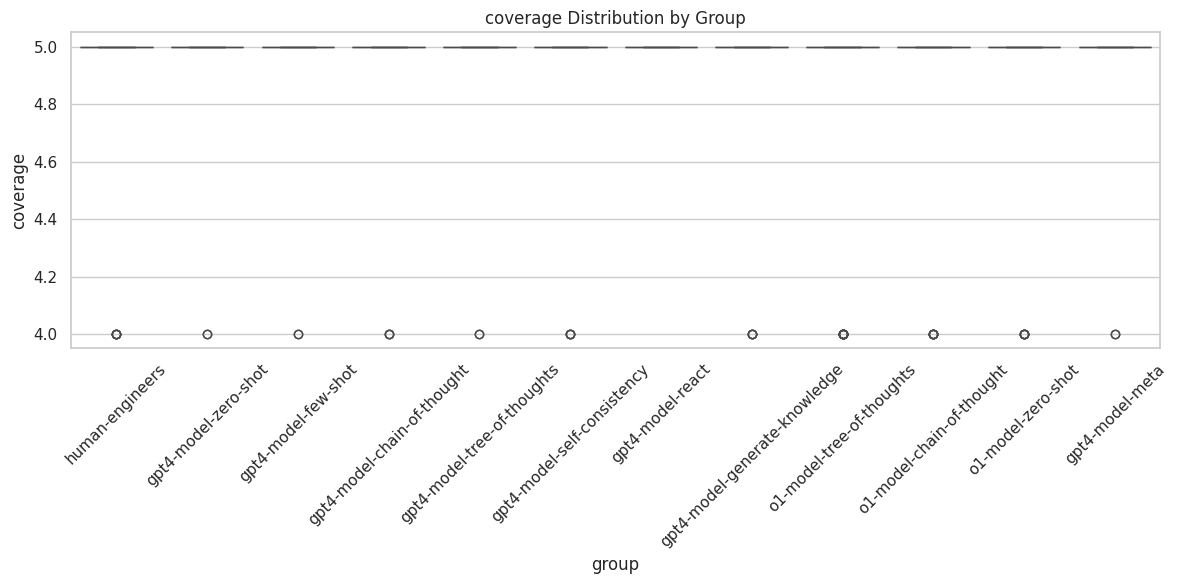

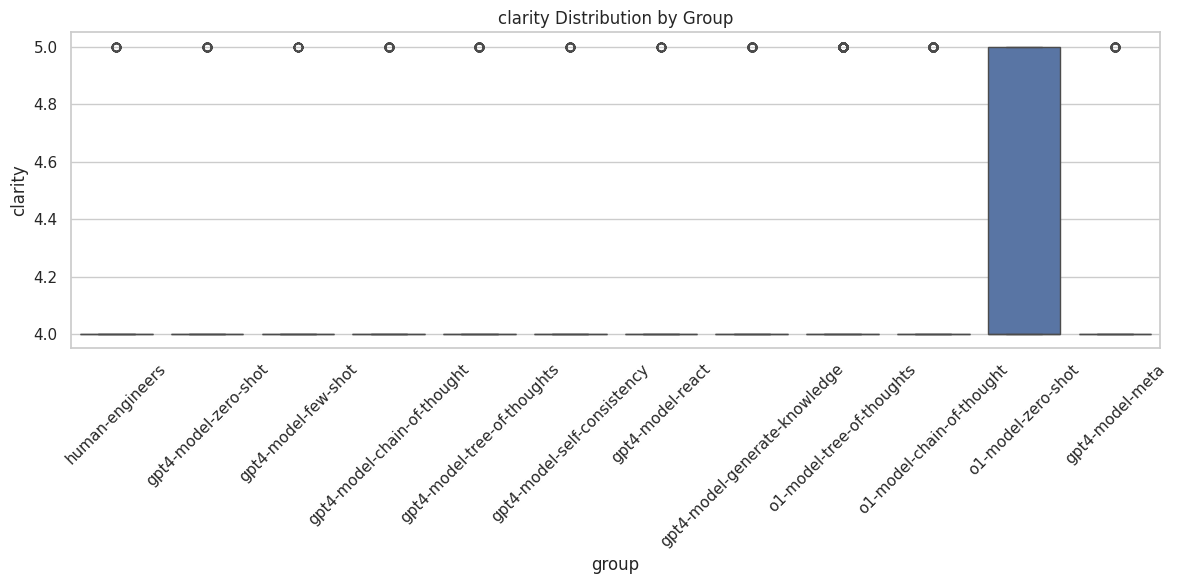

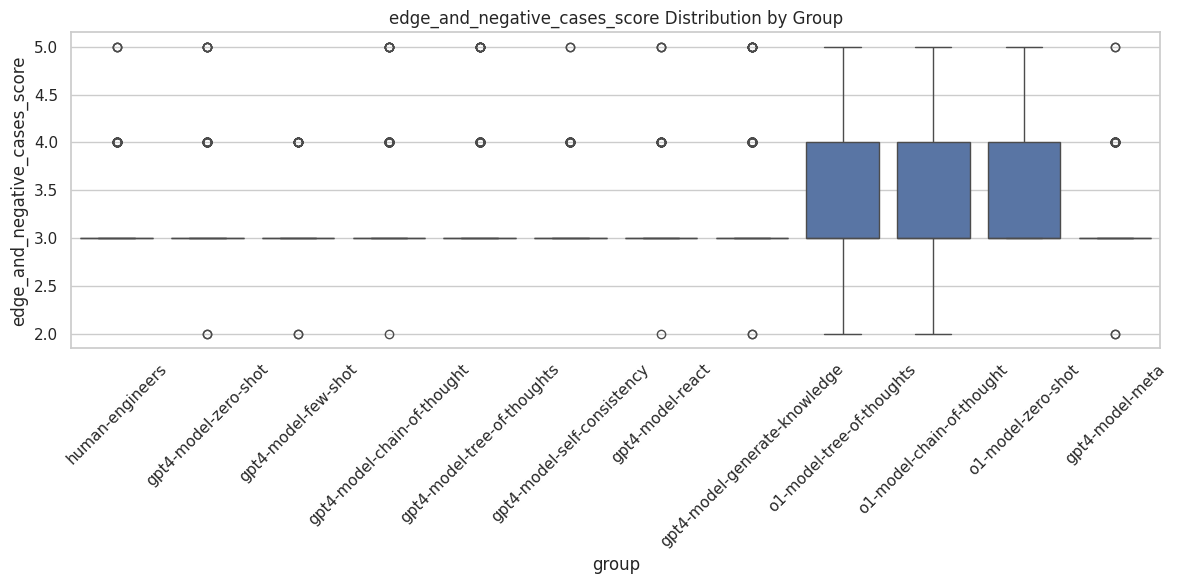

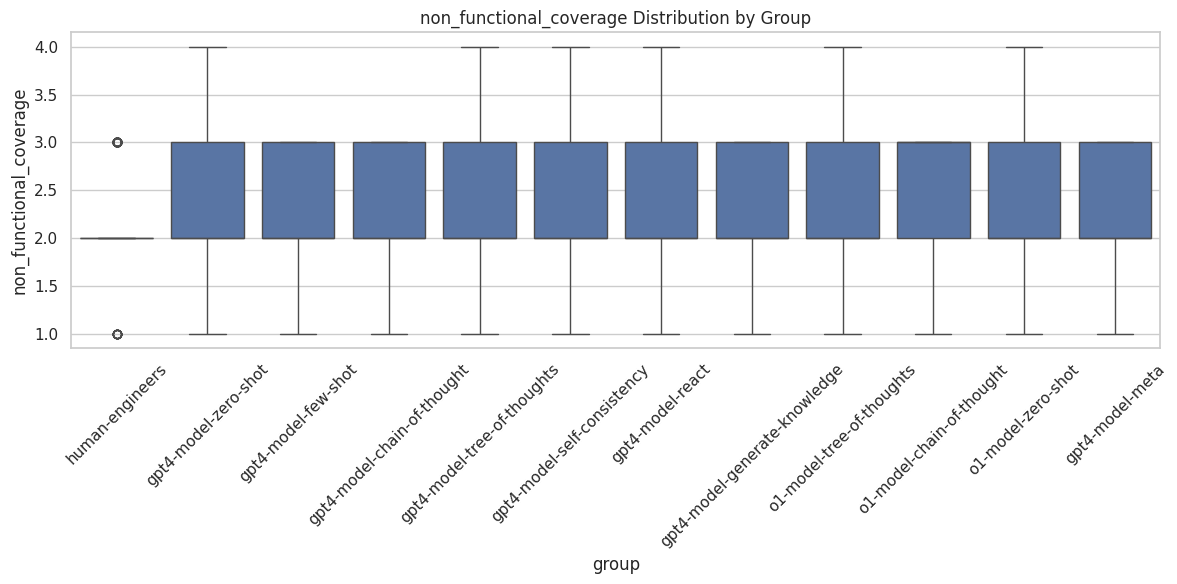

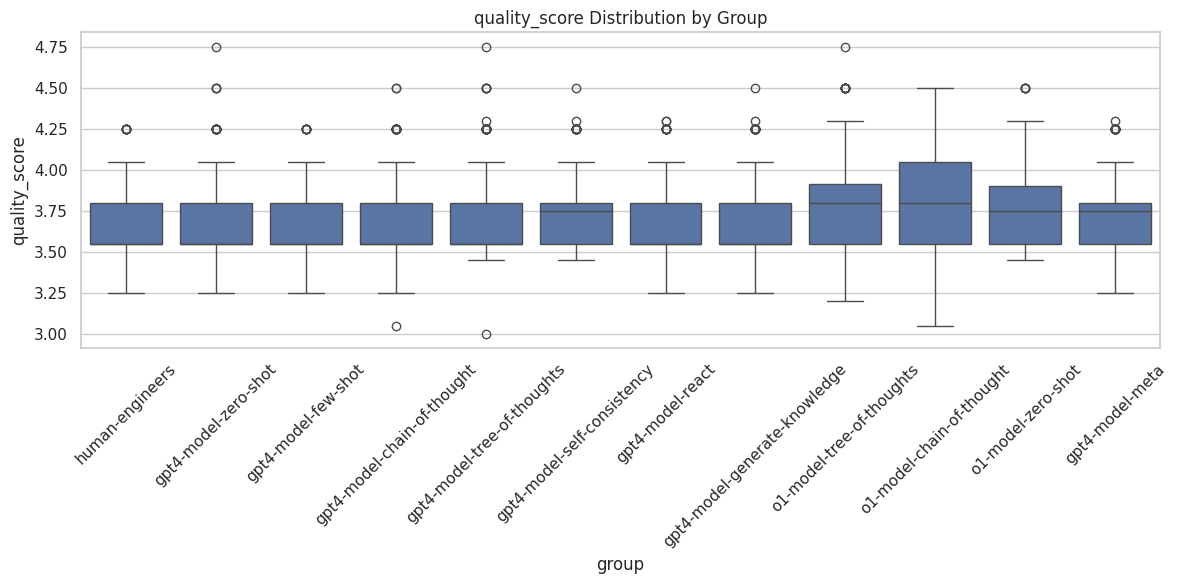

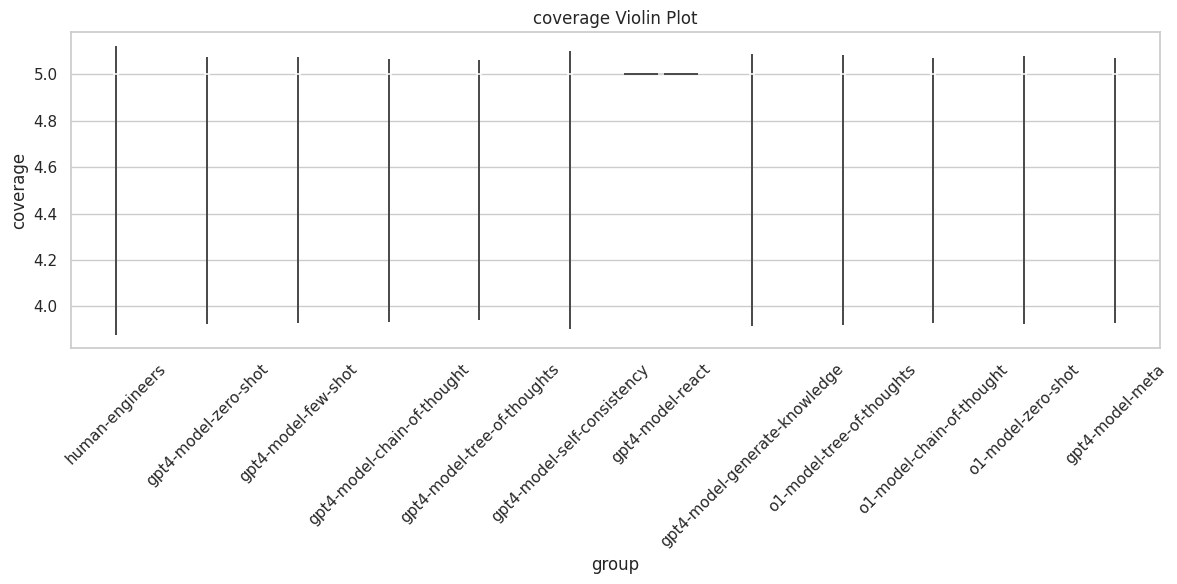

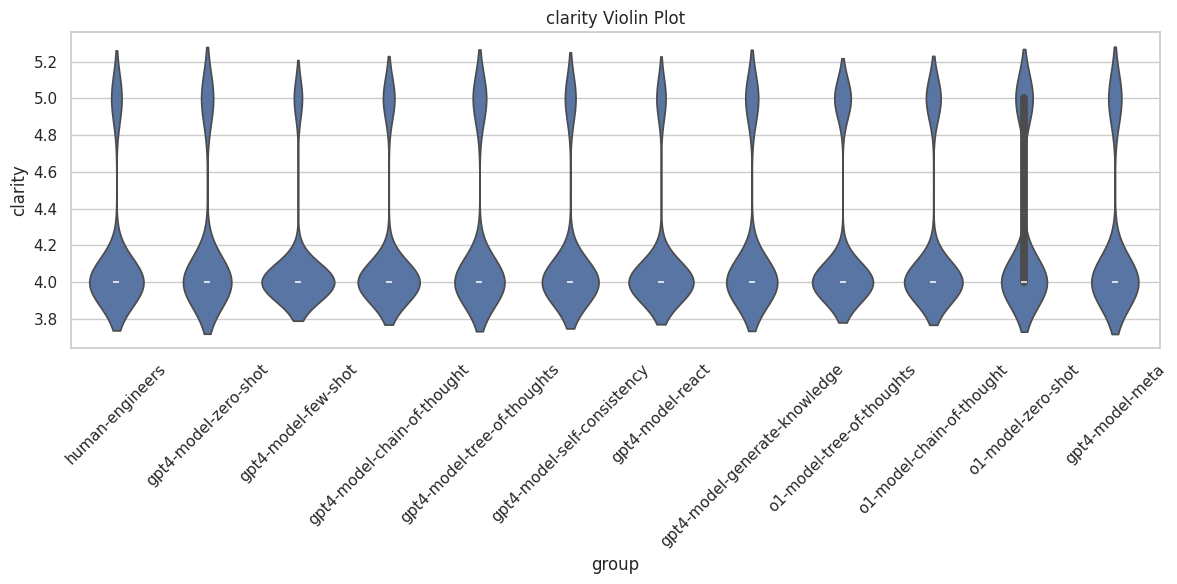

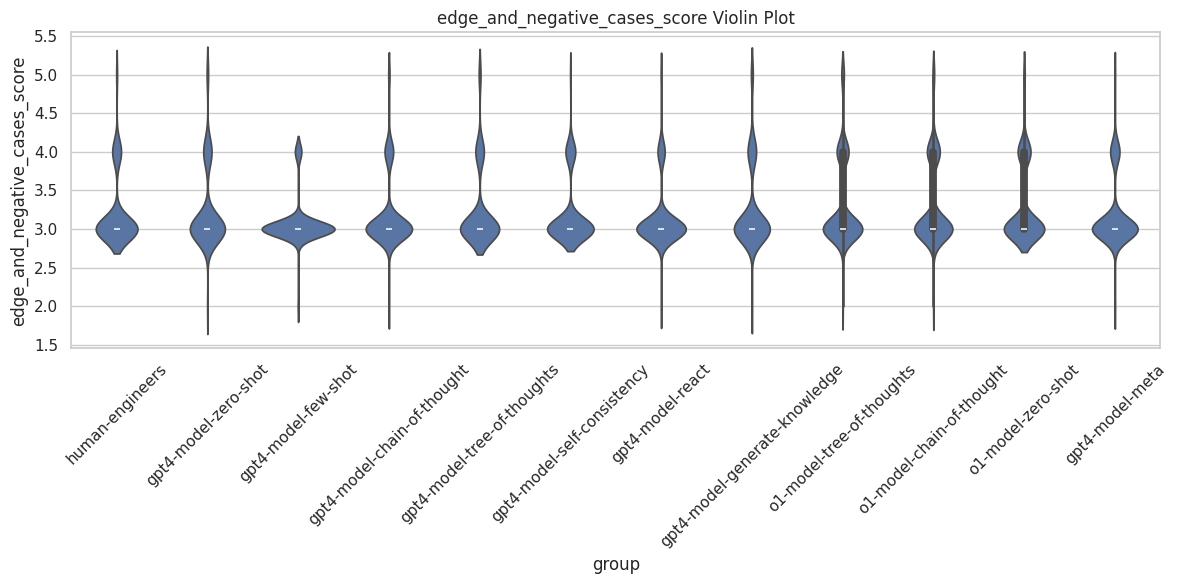

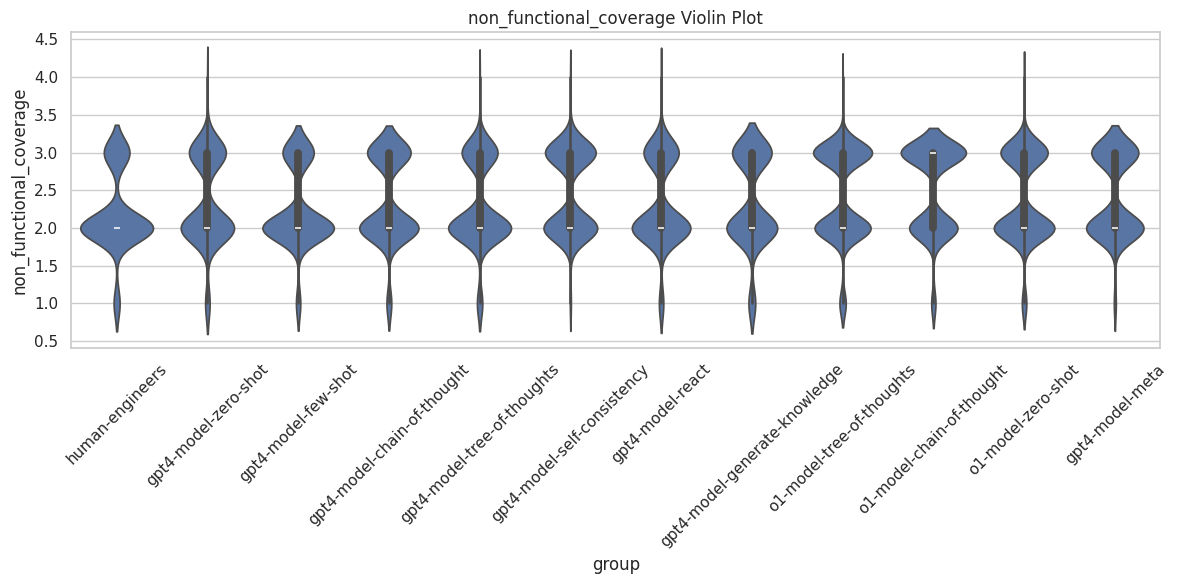

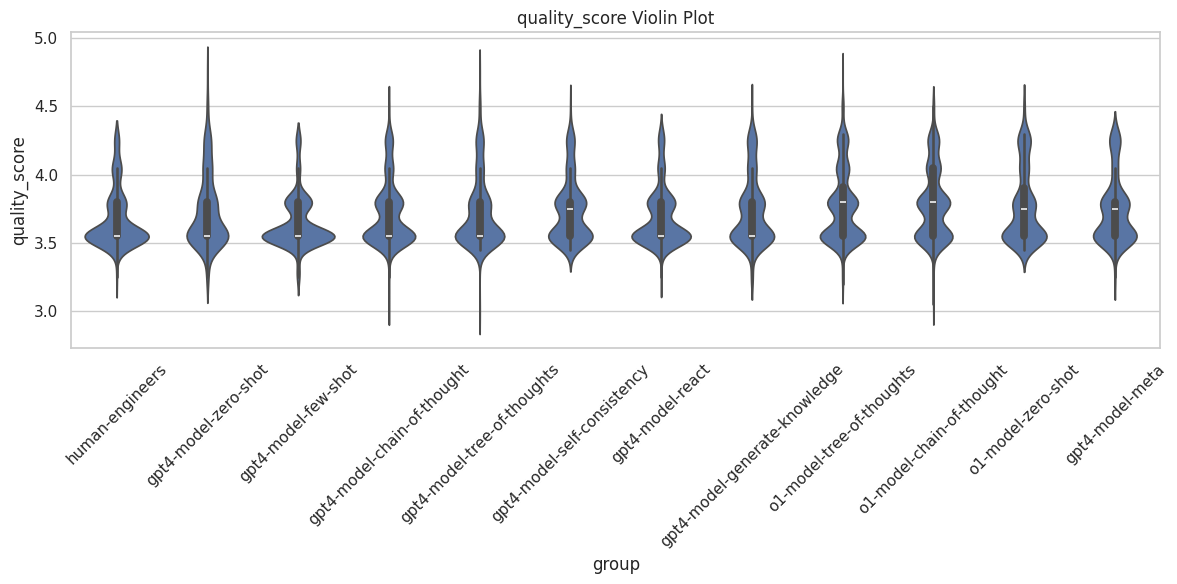

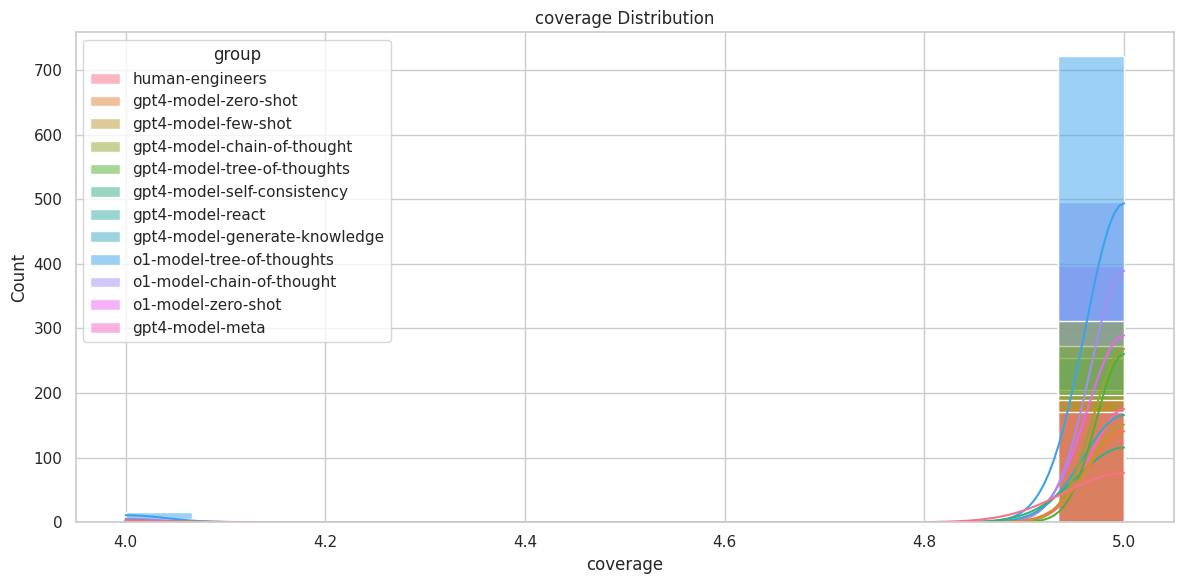

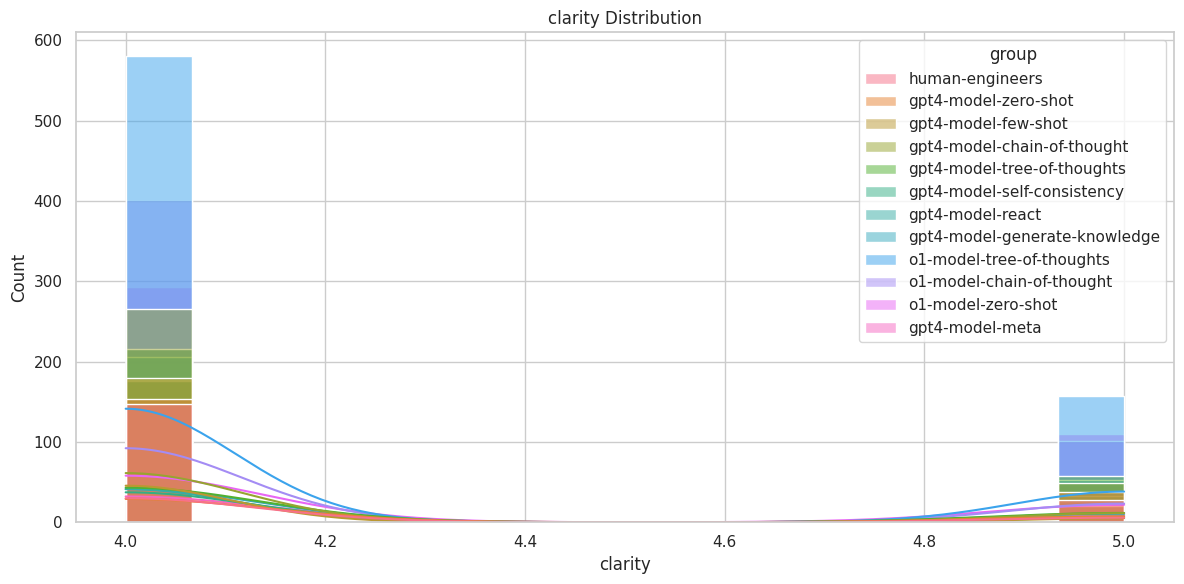

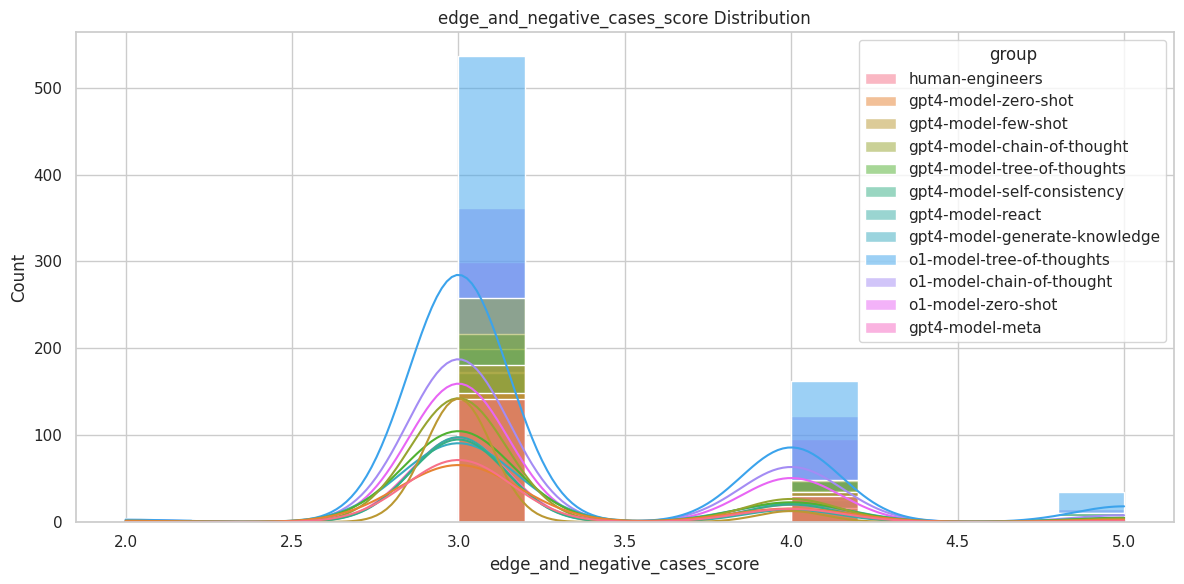

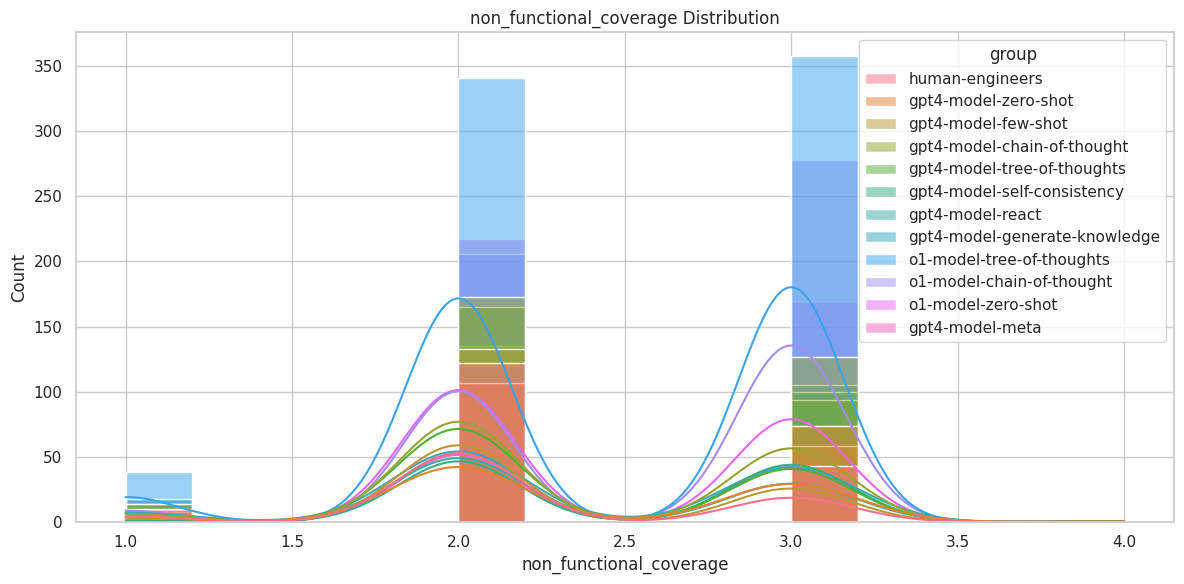

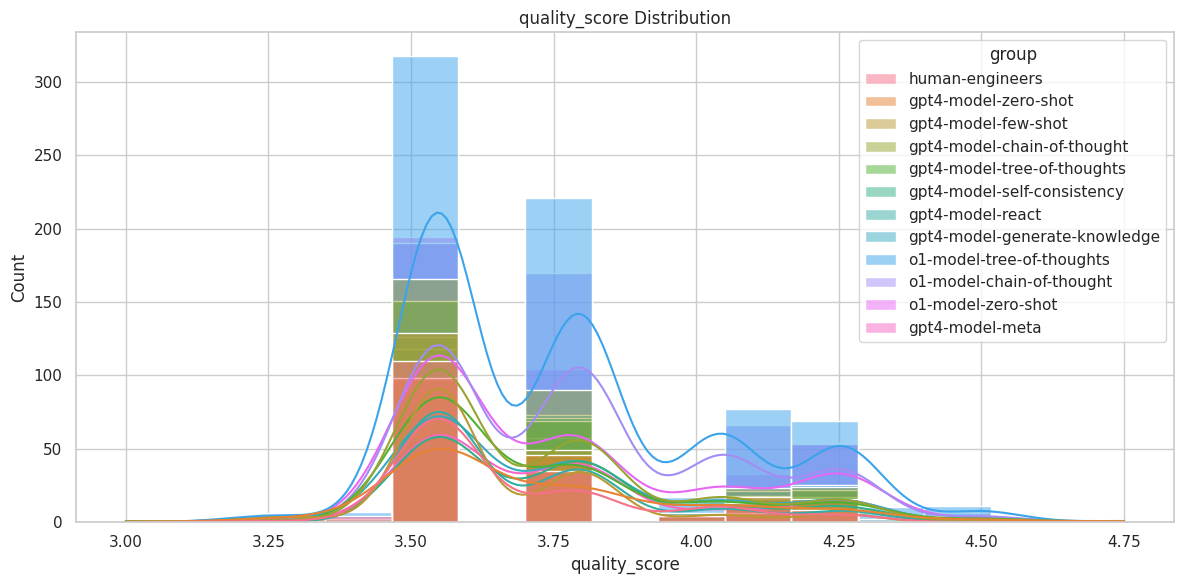

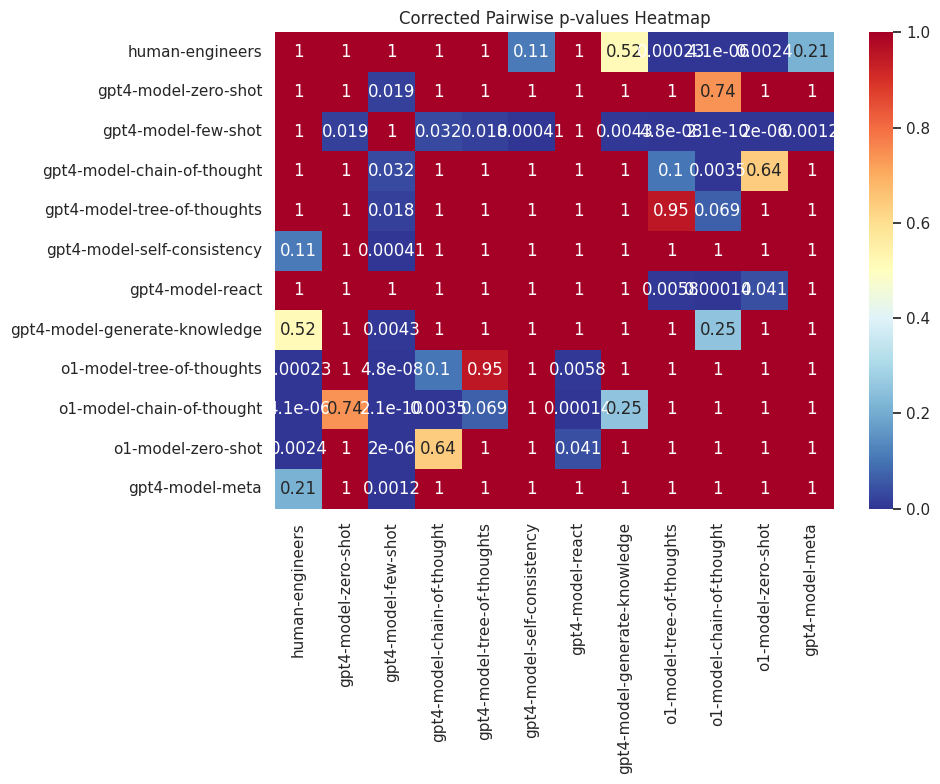

TypeError: keys must be str, int, float, bool or None, not tuple

In [ ]:
# ============================================================
# Google Colab Script:
# Statistical Assumption Testing for Evaluation Dataset
#
# This script performs:
# 1. Shapiro-Wilk Normality Test
# 2. Levene's Homogeneity of Variance Test
# 3. ANOVA
# 4. Pairwise t-tests with Bonferroni correction
# 5. Descriptive Statistics
# 6. Visualizations & Charts
#
# Dataset Input:
# Upload your success.json file directly in Colab.
# ============================================================

# ============================================================
# Install Required Packages
# ============================================================

!pip install scipy seaborn statsmodels --quiet

# ============================================================
# Imports
# ============================================================

import json
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from scipy.stats import (
    shapiro,
    levene,
    f_oneway,
    ttest_ind
)

from statsmodels.stats.multitest import multipletests

# ============================================================
# Upload Dataset
# ============================================================

print("Upload your dataset JSON file (e.g. success.json)")

uploaded = files.upload()

uploaded_file = list(uploaded.keys())[0]

with open(uploaded_file, "r") as f:
    raw_dataset = json.load(f)

print(f"\nLoaded Dataset: {uploaded_file}")
print(f"Total Records: {len(raw_dataset)}")

# ============================================================
# Convert Dataset into Evaluation Format
# ============================================================

def format_data_to_evaluations(dataset):

    evaluations = []

    for result in dataset:

        evaluations.append({
            "test_case_id": result["test_case_id"],
            "group": result["group"],

            "coverage":
                result["evaluation"]["coverage"]["score"],

            "clarity":
                result["evaluation"]["clarity"]["score"],

            "edge_and_negative_cases_score":
                result["evaluation"]["edge_and_negative_cases_score"]["score"],

            "non_functional_coverage":
                result["evaluation"]["non_functional_coverage"]["score"],

            "quality_score":
                (
                    0.30 * result["evaluation"]["coverage"]["score"]
                    + 0.20 * result["evaluation"]["clarity"]["score"]
                    + 0.25 * result["evaluation"]["edge_and_negative_cases_score"]["score"]
                    + 0.25 * result["evaluation"]["non_functional_coverage"]["score"]
                )
        })

    return evaluations

evaluations = format_data_to_evaluations(raw_dataset)

df = pd.DataFrame(evaluations)

# ============================================================
# Create Output Directory
# ============================================================

OUTPUT_DIR = "statistical_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# Display Basic Information
# ============================================================

print("\n====================================================")
print("Dataset Overview")
print("====================================================")

print(df.head())

print("\nGroups:")
print(df["group"].value_counts())

# ============================================================
# Descriptive Statistics
# ============================================================

print("\n====================================================")
print("Descriptive Statistics")
print("====================================================")

metrics = [
    "coverage",
    "clarity",
    "edge_and_negative_cases_score",
    "non_functional_coverage",
    "quality_score"
]

descriptive_stats = df.groupby("group")[metrics].agg([
    "mean",
    "std",
    "median",
    "var",
    "min",
    "max"
])

print(descriptive_stats)

descriptive_stats.to_csv(
    f"{OUTPUT_DIR}/descriptive_statistics.csv"
)

# ============================================================
# SHAPIRO-WILK NORMALITY TEST
# ============================================================

print("\n====================================================")
print("Shapiro-Wilk Normality Test")
print("====================================================")

shapiro_results = []

for metric in metrics:

    print(f"\nMetric: {metric}")
    print("-" * 50)

    for group in df["group"].unique():

        values = df[df["group"] == group][metric]

        stat, p = shapiro(values)

        interpretation = (
            "Normally Distributed"
            if p > 0.05
            else "NOT Normally Distributed"
        )

        print(
            f"{group:<30} "
            f"W={stat:.4f} | "
            f"p={p:.6f} | "
            f"{interpretation}"
        )

        shapiro_results.append({
            "metric": metric,
            "group": group,
            "W_statistic": stat,
            "p_value": p,
            "interpretation": interpretation
        })

shapiro_df = pd.DataFrame(shapiro_results)

shapiro_df.to_csv(
    f"{OUTPUT_DIR}/shapiro_wilk_results.csv",
    index=False
)

# ============================================================
# LEVENE'S TEST
# ============================================================

print("\n====================================================")
print("Levene's Test for Homogeneity of Variance")
print("====================================================")

levene_results = []

for metric in metrics:

    grouped_data = [
        group_df[metric].values
        for _, group_df in df.groupby("group")
    ]

    stat, p = levene(*grouped_data)

    interpretation = (
        "Equal Variances Assumed"
        if p > 0.05
        else "Variances are Significantly Different"
    )

    print(
        f"{metric:<40} "
        f"Statistic={stat:.4f} | "
        f"p={p:.6f} | "
        f"{interpretation}"
    )

    levene_results.append({
        "metric": metric,
        "levene_statistic": stat,
        "p_value": p,
        "interpretation": interpretation
    })

levene_df = pd.DataFrame(levene_results)

levene_df.to_csv(
    f"{OUTPUT_DIR}/levene_results.csv",
    index=False
)

# ============================================================
# ANOVA
# ============================================================

print("\n====================================================")
print("ANOVA Results")
print("====================================================")

anova_results = []

for metric in metrics:

    grouped_data = [
        group_df[metric].values
        for _, group_df in df.groupby("group")
    ]

    stat, p = f_oneway(*grouped_data)

    interpretation = (
        "Significant Difference"
        if p < 0.05
        else "No Significant Difference"
    )

    print(
        f"{metric:<40} "
        f"F={stat:.4f} | "
        f"p={p:.6f} | "
        f"{interpretation}"
    )

    anova_results.append({
        "metric": metric,
        "F_statistic": stat,
        "p_value": p,
        "interpretation": interpretation
    })

anova_df = pd.DataFrame(anova_results)

anova_df.to_csv(
    f"{OUTPUT_DIR}/anova_results.csv",
    index=False
)

# ============================================================
# Pairwise t-tests with Bonferroni Correction
# ============================================================

print("\n====================================================")
print("Pairwise t-tests")
print("====================================================")

pairwise_results = []

groups = df["group"].unique()

for metric in metrics:

    temp_results = []
    p_values = []

    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):

            group1 = groups[i]
            group2 = groups[j]

            values1 = df[df["group"] == group1][metric]
            values2 = df[df["group"] == group2][metric]

            t_stat, p = ttest_ind(values1, values2)

            temp_results.append({
                "metric": metric,
                "group_1": group1,
                "group_2": group2,
                "t_statistic": t_stat,
                "raw_p_value": p
            })

            p_values.append(p)

    # Bonferroni Correction
    corrected = multipletests(
        p_values,
        method="bonferroni"
    )

    corrected_p_values = corrected[1]

    for idx, result in enumerate(temp_results):

        corrected_p = corrected_p_values[idx]

        result["corrected_p_value"] = corrected_p

        result["interpretation"] = (
            "Significant"
            if corrected_p < 0.05
            else "Not Significant"
        )

        pairwise_results.append(result)

pairwise_df = pd.DataFrame(pairwise_results)

print(pairwise_df)

pairwise_df.to_csv(
    f"{OUTPUT_DIR}/pairwise_ttest_results.csv",
    index=False
)

# ============================================================
# VISUALIZATIONS
# ============================================================

sns.set(style="whitegrid")

# ------------------------------------------------------------
# Boxplots
# ------------------------------------------------------------

for metric in metrics:

    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=df,
        x="group",
        y=metric
    )

    plt.xticks(rotation=45)

    plt.title(f"{metric} Distribution by Group")

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{metric}_boxplot.png",
        dpi=300
    )

    plt.show()

# ------------------------------------------------------------
# Violin Plots
# ------------------------------------------------------------

for metric in metrics:

    plt.figure(figsize=(12, 6))

    sns.violinplot(
        data=df,
        x="group",
        y=metric
    )

    plt.xticks(rotation=45)

    plt.title(f"{metric} Violin Plot")

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{metric}_violin.png",
        dpi=300
    )

    plt.show()

# ------------------------------------------------------------
# Histogram Distribution
# ------------------------------------------------------------

for metric in metrics:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        data=df,
        x=metric,
        hue="group",
        kde=True,
        bins=15
    )

    plt.title(f"{metric} Distribution")

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{metric}_histogram.png",
        dpi=300
    )

    plt.show()

# ------------------------------------------------------------
# Heatmap of Pairwise Corrected p-values
# ------------------------------------------------------------

quality_df = pairwise_df[
    pairwise_df["metric"] == "quality_score"
]

heatmap_data = pd.DataFrame(
    np.ones((len(groups), len(groups))),
    index=groups,
    columns=groups
)

for _, row in quality_df.iterrows():

    g1 = row["group_1"]
    g2 = row["group_2"]

    heatmap_data.loc[g1, g2] = row["corrected_p_value"]
    heatmap_data.loc[g2, g1] = row["corrected_p_value"]

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1
)

plt.title("Corrected Pairwise p-values Heatmap")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/pairwise_heatmap.png",
    dpi=300
)

plt.show()

# ============================================================
# Save Final Combined Report
# ============================================================

combined_report = {
    "descriptive_statistics":
        descriptive_stats.reset_index().to_dict(),

    "shapiro_results":
        shapiro_df.to_dict(orient="records"),

    "levene_results":
        levene_df.to_dict(orient="records"),

    "anova_results":
        anova_df.to_dict(orient="records"),

    "pairwise_ttests":
        pairwise_df.to_dict(orient="records")
}

with open(f"{OUTPUT_DIR}/complete_statistical_report.json", "w") as f:
    json.dump(combined_report, f, indent=4)

print("\n====================================================")
print("ALL ANALYSIS COMPLETED")
print("====================================================")

print(f"\nResults saved in folder: {OUTPUT_DIR}")

print("\nGenerated Files:")
print("- Descriptive Statistics CSV")
print("- Shapiro-Wilk Results CSV")
print("- Levene Test Results CSV")
print("- ANOVA Results CSV")
print("- Pairwise t-test Results CSV")
print("- Multiple Charts & Visualizations")
print("- Final Combined JSON Report")

## Download & Delete Results

In [ ]:
import shutil
from google.colab import files
import os

# Define the directory to zip and the output filename
folder_to_zip = '/content/statistical_results'
output_zip = 'statistical_results_archive'

if os.path.exists(folder_to_zip):
    # Create the zip archive
    shutil.make_archive(output_zip, 'zip', folder_to_zip)

    # Download the created zip file
    files.download(f'{output_zip}.zip')
    print(f"Successfully zipped {folder_to_zip} and started download.")

    # Delete after download
    shutil.rmtree(folder_to_zip)
    print(f"{folder_to_zip} has been deleted.")
else:
    print(f"Error: The folder {folder_to_zip} does not exist.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully zipped /content/statistical_results and started download.
/content/statistical_results has been deleted.


# Run:
* Kruskal-Wallis Test + Pairwise Mann-Whitney U Tests

Upload your dataset JSON file now.


Saving test_cases_scores.json to test_cases_scores.json

Loaded file: test_cases_scores.json
Total records: 3682

Groups found:
['gpt4-model-chain-of-thought', 'gpt4-model-few-shot', 'gpt4-model-generate-knowledge', 'gpt4-model-meta', 'gpt4-model-react', 'gpt4-model-self-consistency', 'gpt4-model-tree-of-thoughts', 'gpt4-model-zero-shot', 'human-engineers', 'o1-model-chain-of-thought', 'o1-model-tree-of-thoughts', 'o1-model-zero-shot']

Descriptive Statistics
                              coverage                                     \
                                 count      mean       std median min max   
group                                                                       
gpt4-model-chain-of-thought        314  4.990446  0.097432    5.0   4   5   
gpt4-model-few-shot                199  4.989950  0.099997    5.0   4   5   
gpt4-model-generate-knowledge      258  4.984496  0.123786    5.0   4   5   
gpt4-model-meta                    217  4.990783  0.095781    5.0   4   5 

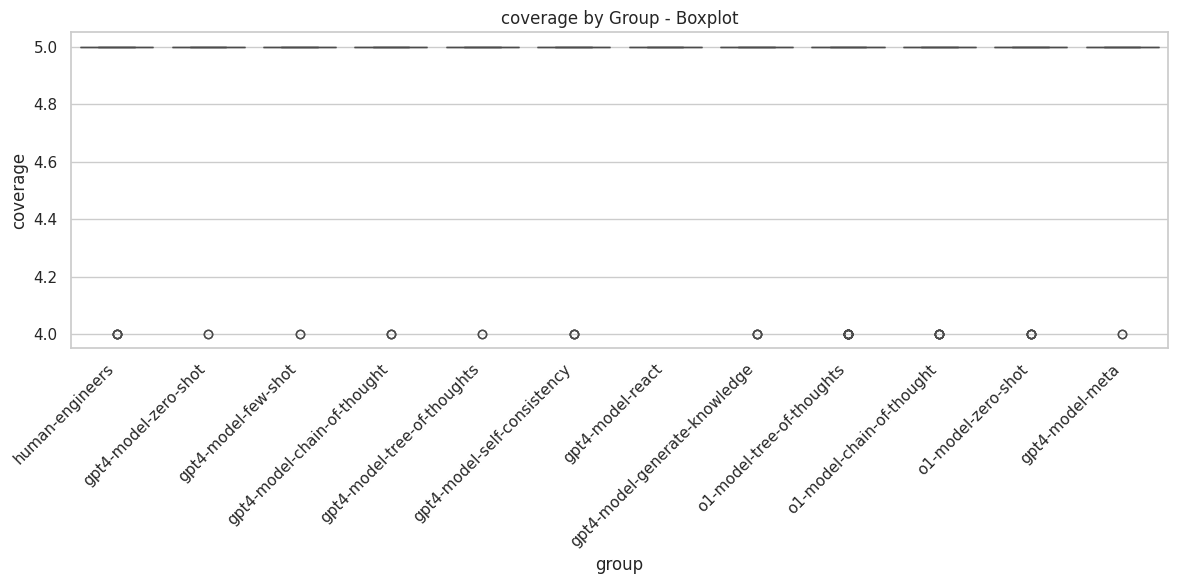

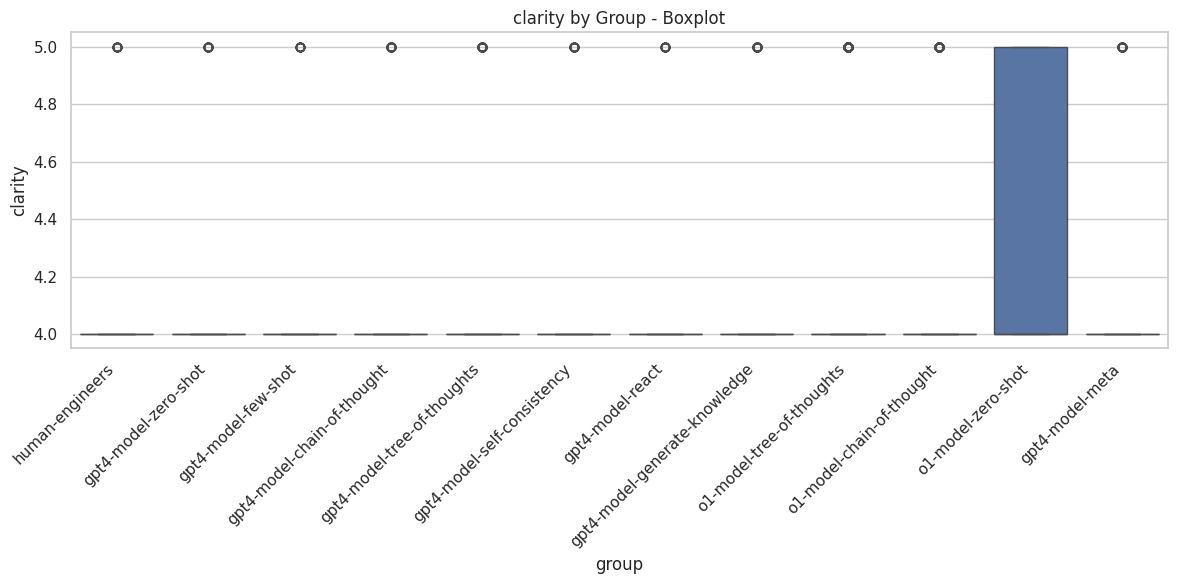

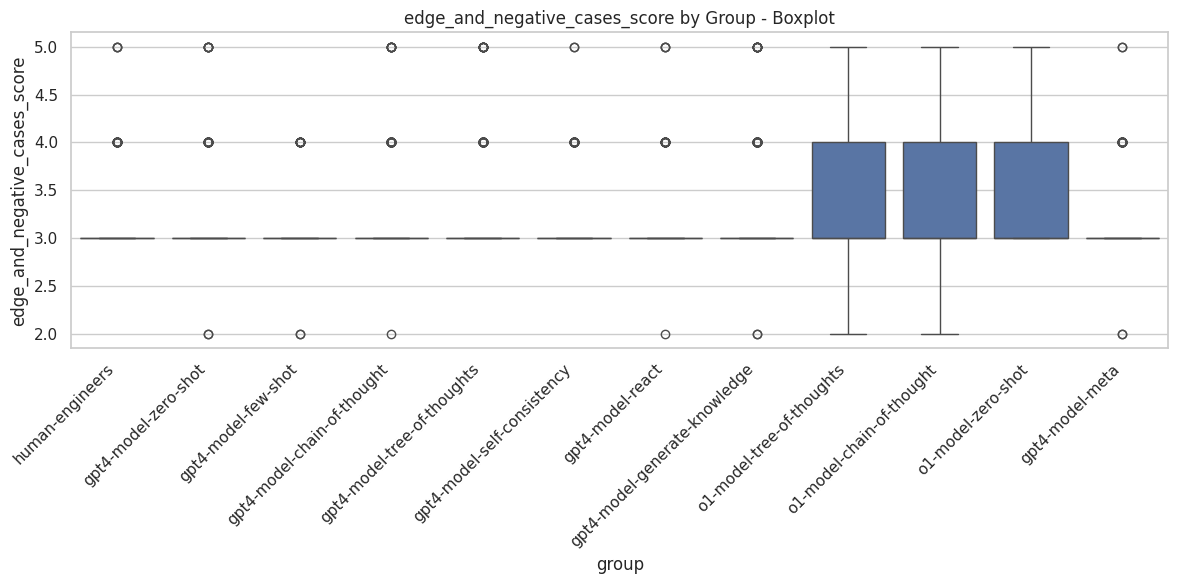

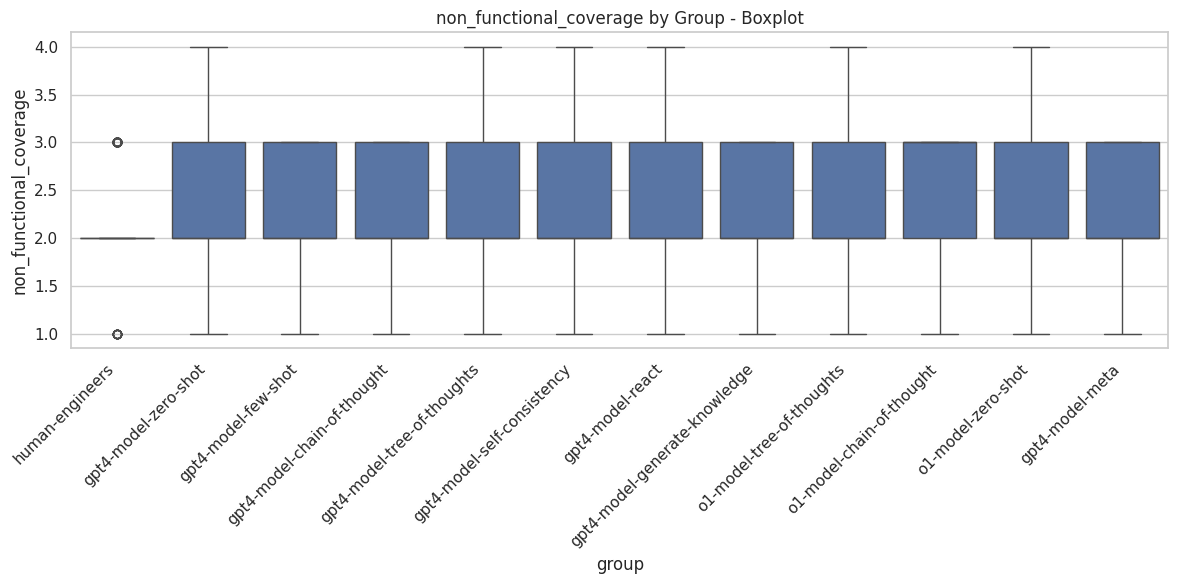

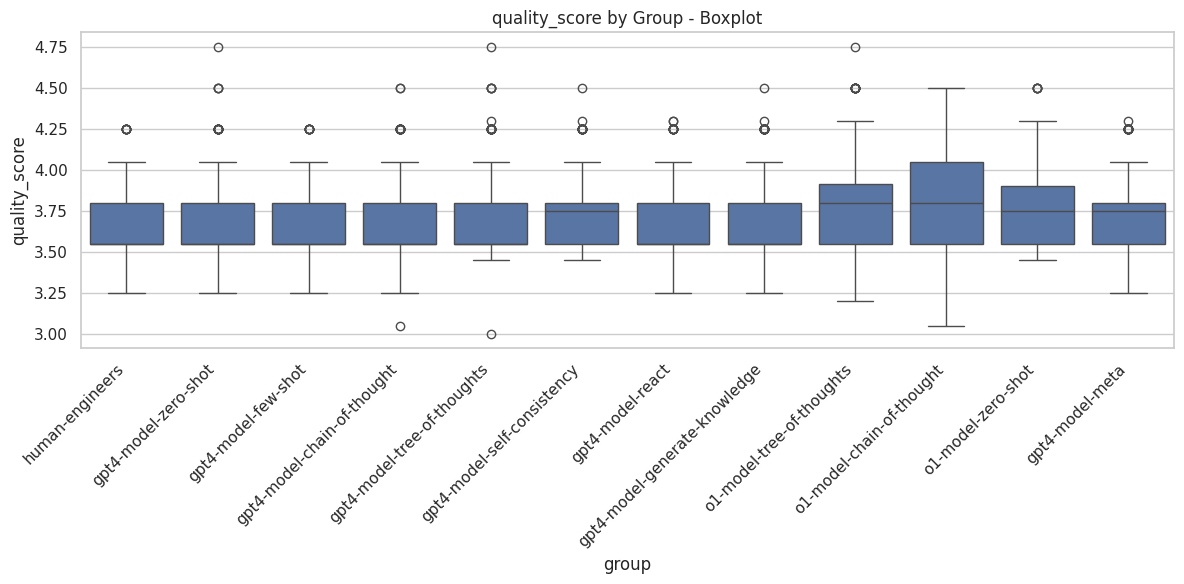

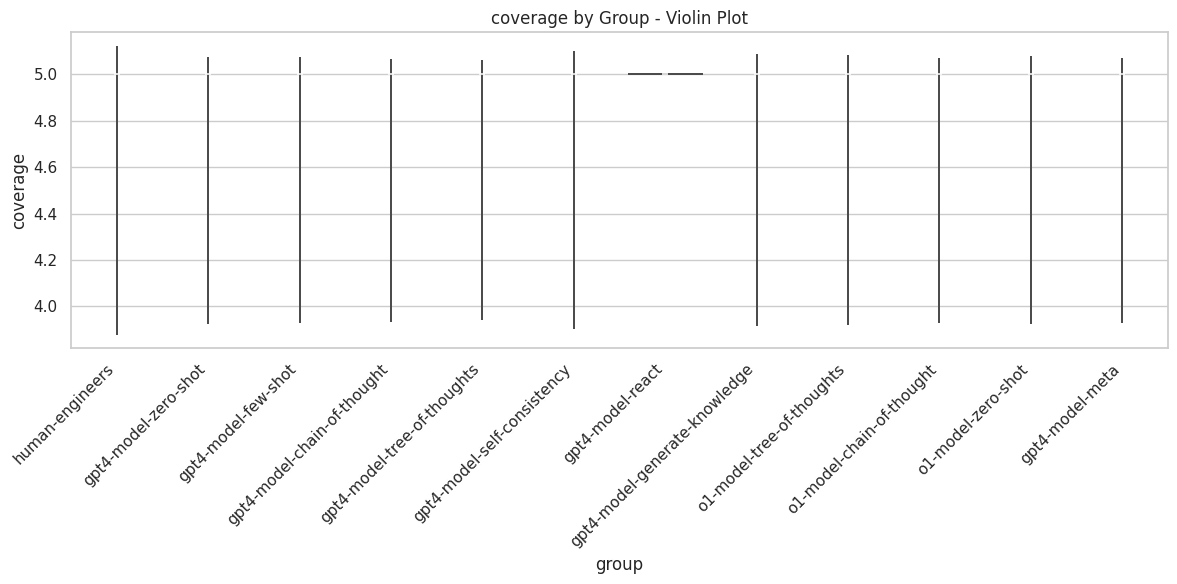

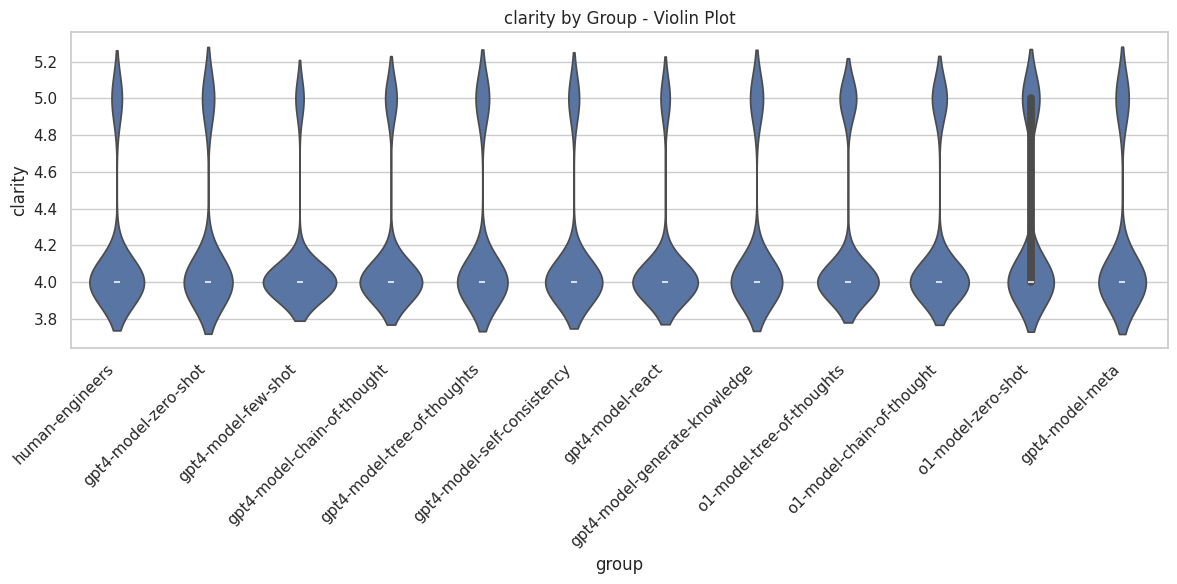

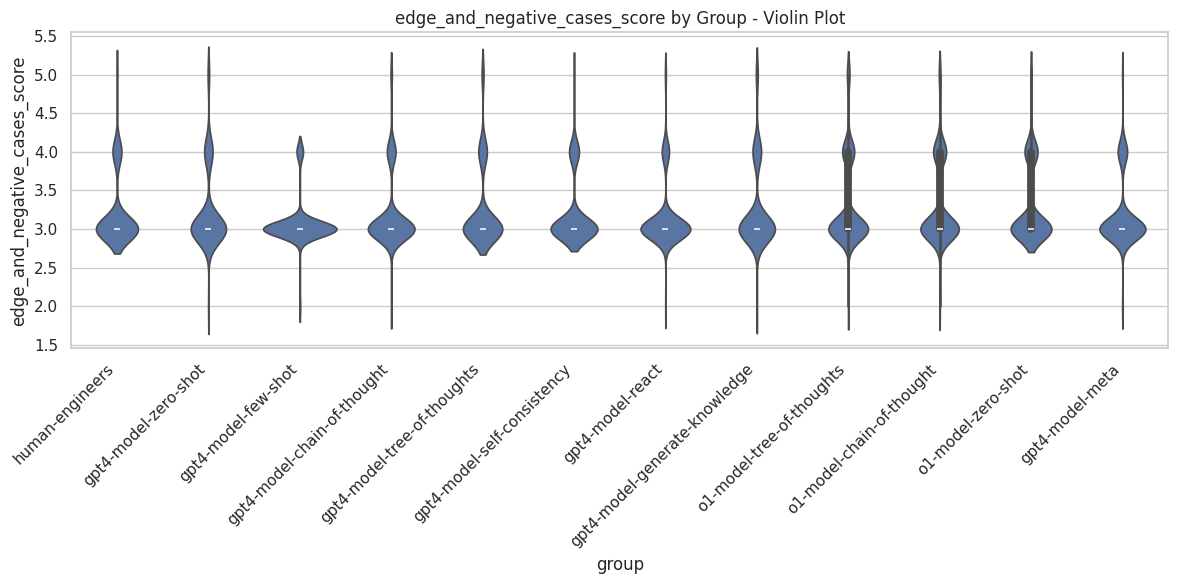

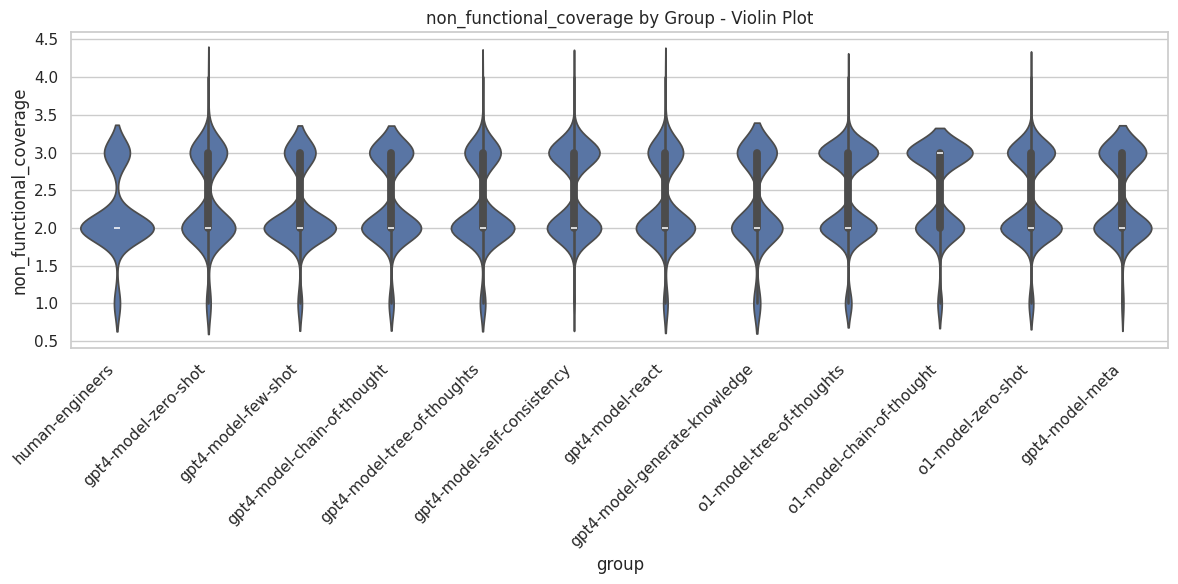

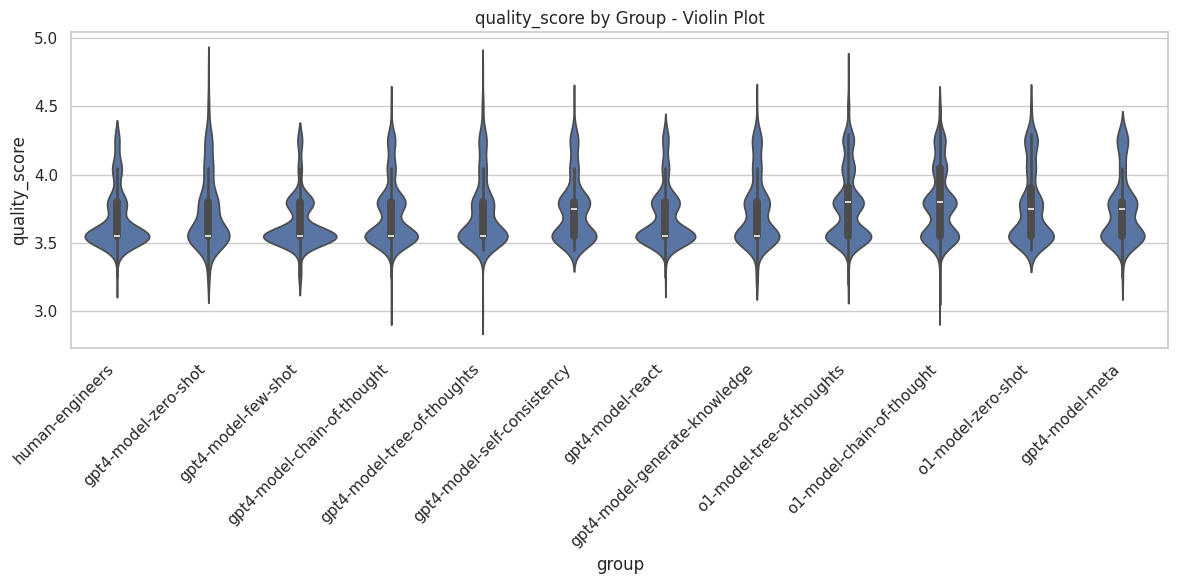

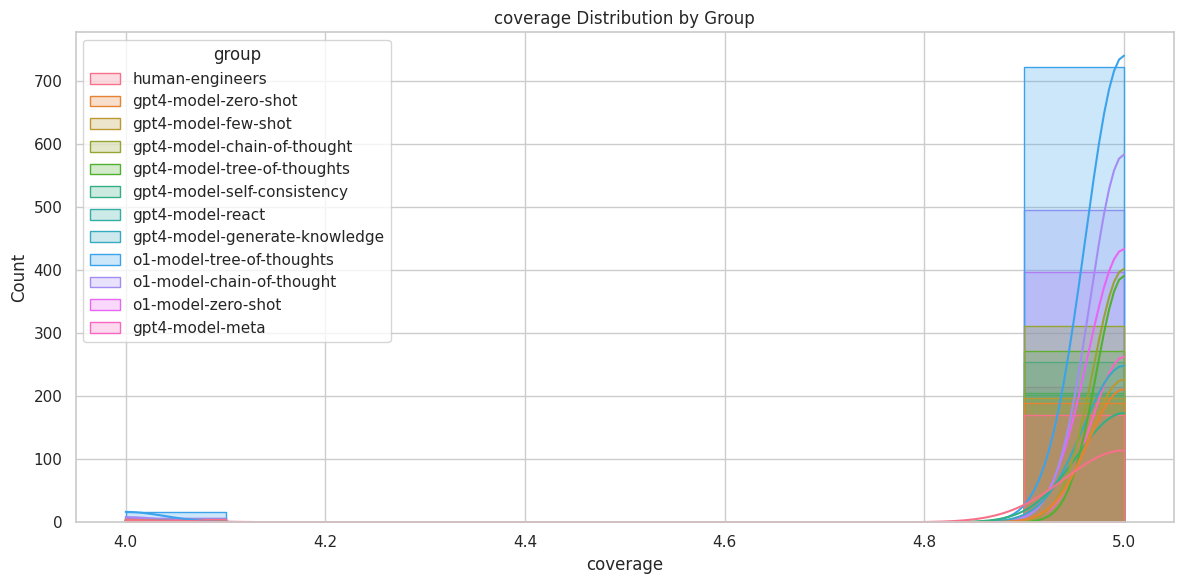

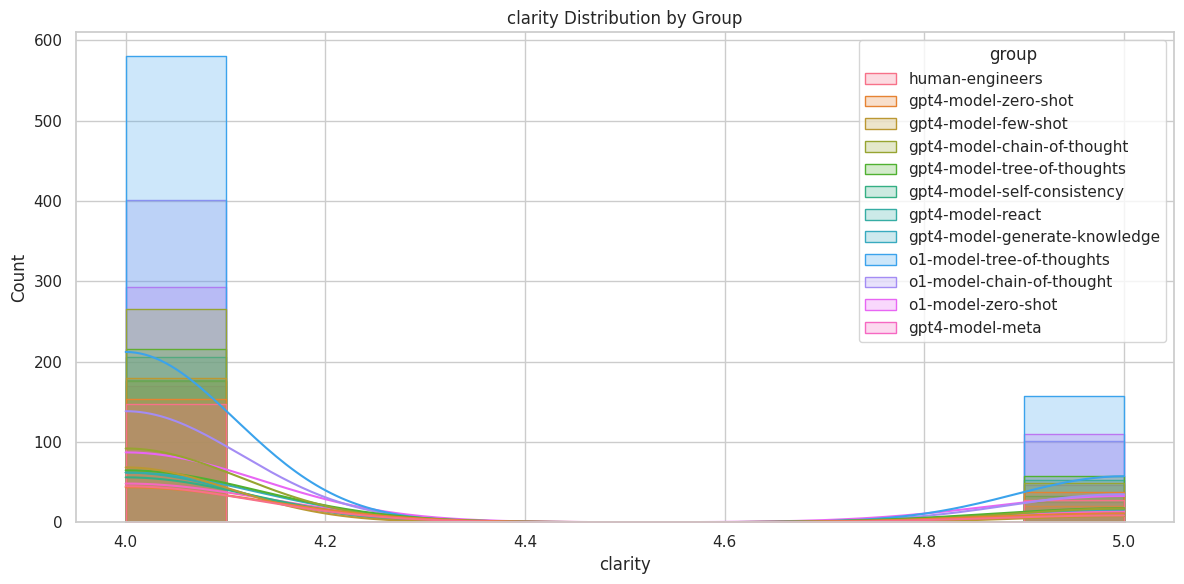

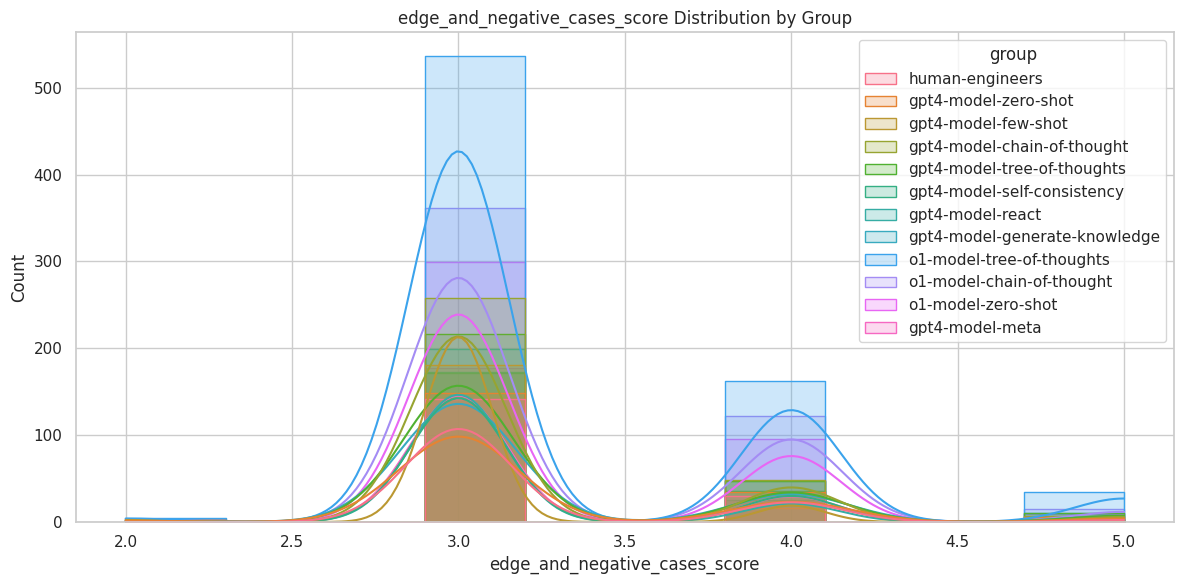

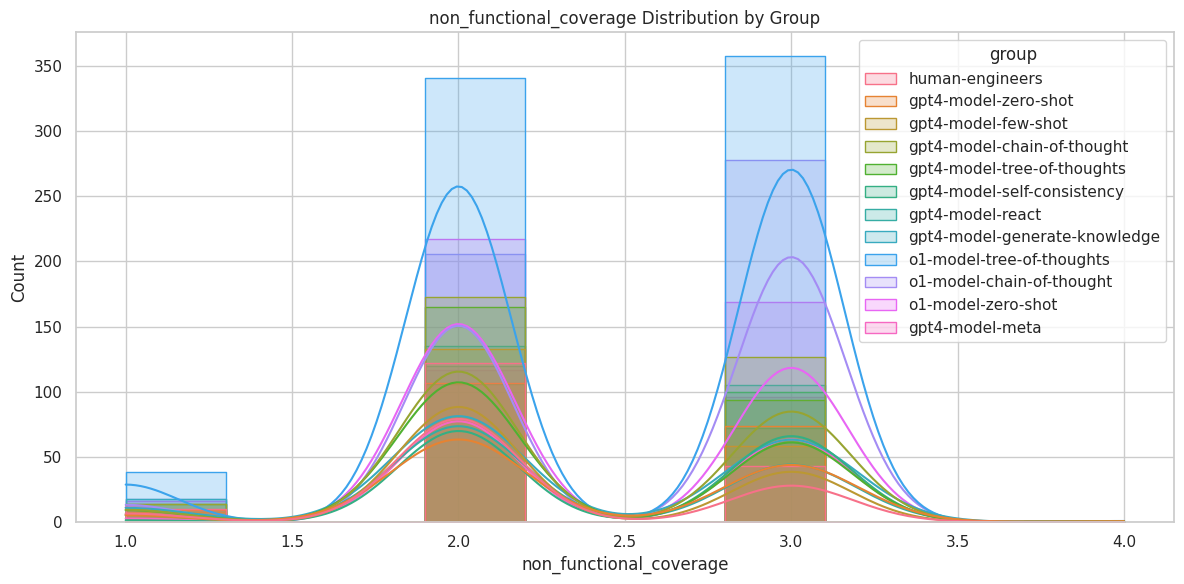

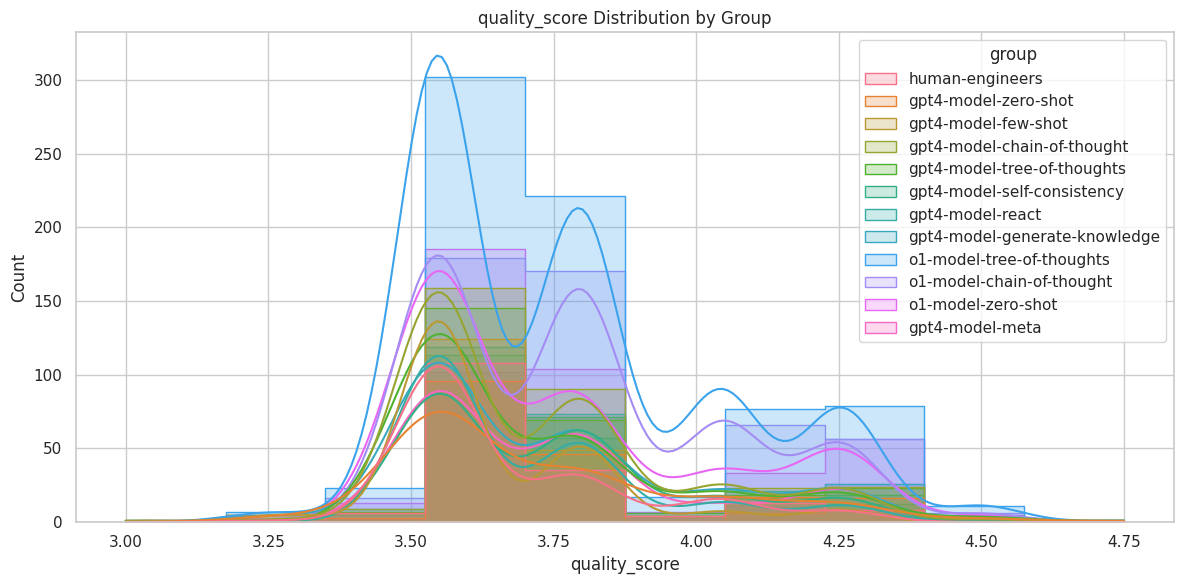

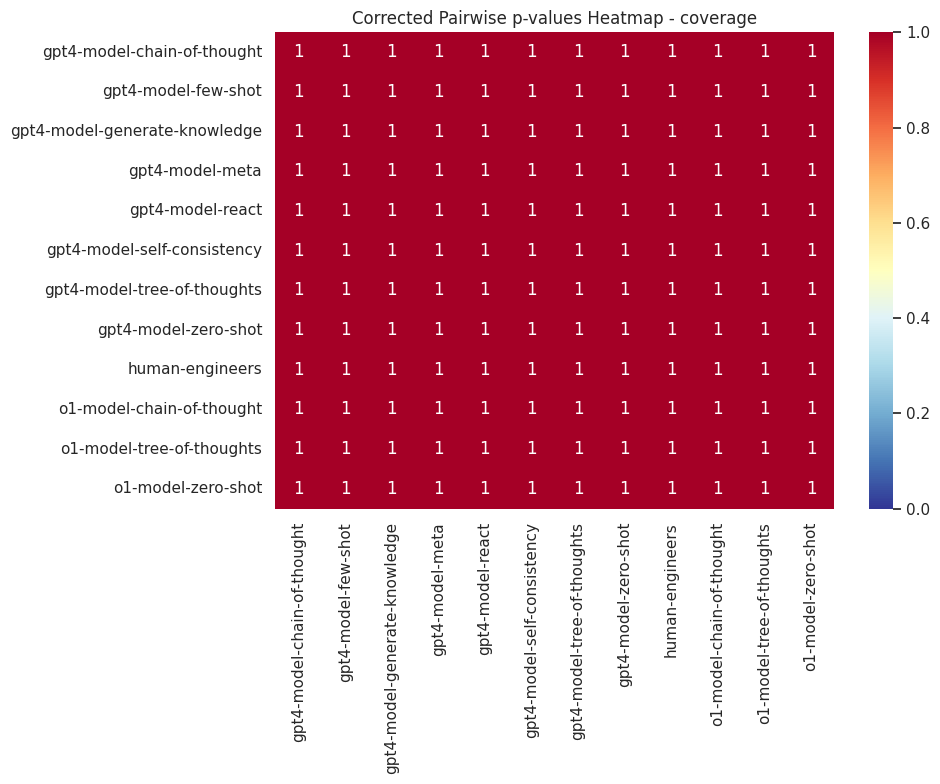

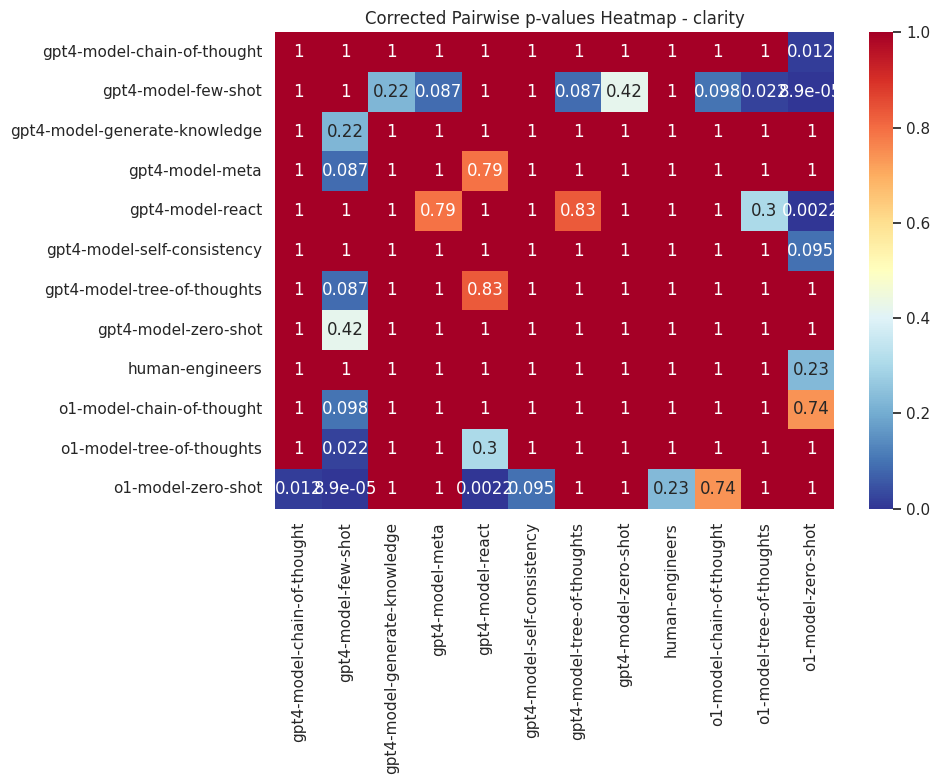

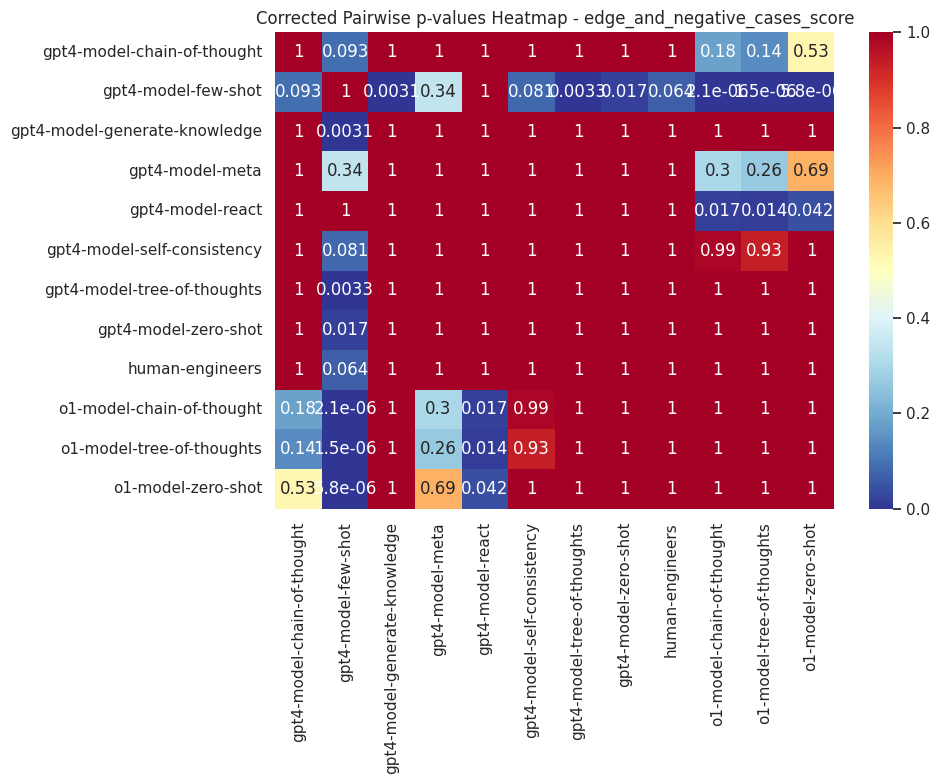

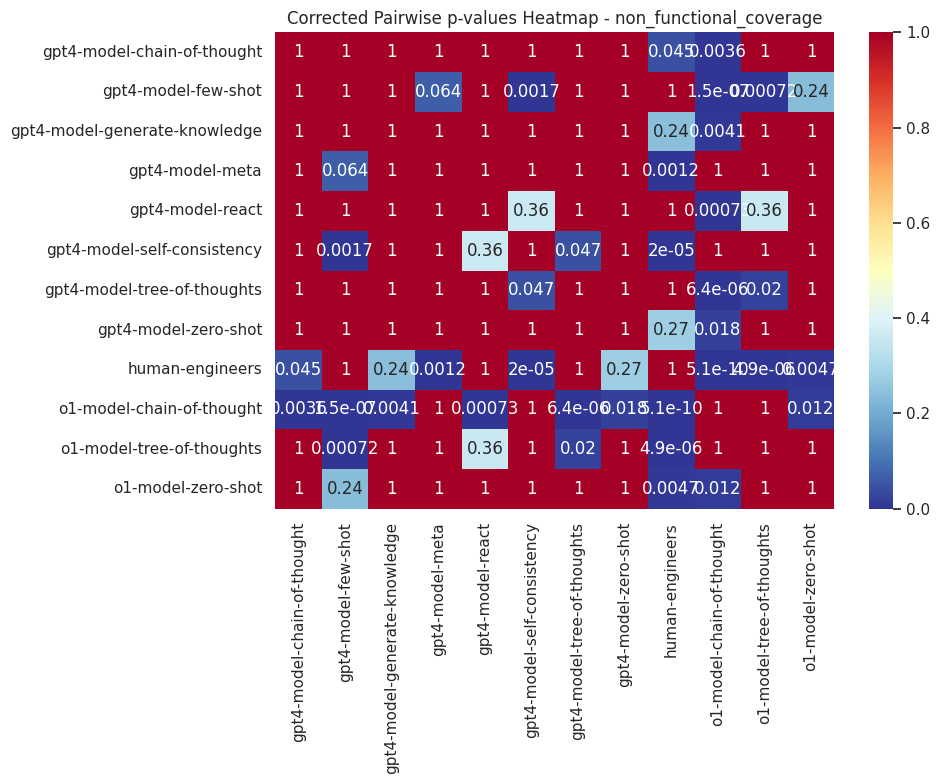

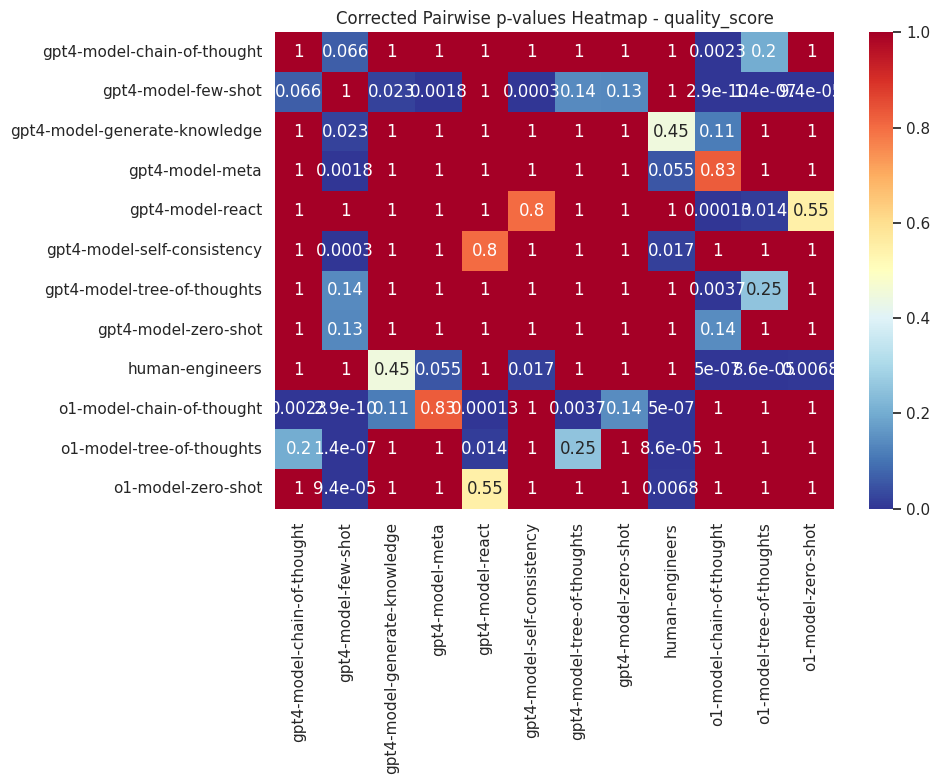

TypeError: keys must be str, int, float, bool or None, not tuple

In [15]:
# ============================================================
# Google Colab Script:
# Kruskal-Wallis Test + Pairwise Mann-Whitney U Tests
#
# What it does:
# 1. Uploads your JSON dataset from Colab file upload
# 2. Converts it to evaluation format
# 3. Runs descriptive statistics
# 4. Runs Kruskal-Wallis test for each metric
# 5. Runs pairwise Mann-Whitney U tests
# 6. Applies multiple-comparison correction
# 7. Saves tables, CSVs, and charts
# ============================================================

!pip install scipy seaborn statsmodels --quiet

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ============================================================
# Upload Dataset
# ============================================================

print("Upload your dataset JSON file now.")
uploaded = files.upload()

uploaded_file = list(uploaded.keys())[0]

with open(uploaded_file, "r", encoding="utf-8") as f:
    raw_dataset = json.load(f)

print(f"\nLoaded file: {uploaded_file}")
print(f"Total records: {len(raw_dataset)}")

# ============================================================
# Convert Raw Dataset to Evaluation DataFrame
# ============================================================

def format_data_to_evaluations(dataset):
    evaluations = []

    for result in dataset:
        evaluations.append({
            "test_case_id": result["test_case_id"],
            "group": result["group"],

            "coverage": result["evaluation"]["coverage"]["score"],
            "clarity": result["evaluation"]["clarity"]["score"],
            "edge_and_negative_cases_score": result["evaluation"]["edge_and_negative_cases_score"]["score"],
            "non_functional_coverage": result["evaluation"]["non_functional_coverage"]["score"],

            "quality_score": (
                0.30 * result["evaluation"]["coverage"]["score"]
                + 0.20 * result["evaluation"]["clarity"]["score"]
                + 0.25 * result["evaluation"]["edge_and_negative_cases_score"]["score"]
                + 0.25 * result["evaluation"]["non_functional_coverage"]["score"]
            )
        })

    return evaluations

evaluations = format_data_to_evaluations(raw_dataset)
df = pd.DataFrame(evaluations)

# ============================================================
# Output Directory
# ============================================================

OUTPUT_DIR = "nonparametric_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# Metrics
# ============================================================

metrics = [
    "coverage",
    "clarity",
    "edge_and_negative_cases_score",
    "non_functional_coverage",
    "quality_score"
]

groups = sorted(df["group"].dropna().unique())

print("\nGroups found:")
print(groups)

# ============================================================
# Descriptive Statistics
# ============================================================

print("\n====================================================")
print("Descriptive Statistics")
print("====================================================")

desc_stats = df.groupby("group")[metrics].agg([
    "count", "mean", "std", "median", "min", "max"
])

print(desc_stats)

desc_stats.to_csv(f"{OUTPUT_DIR}/descriptive_statistics.csv")

# ============================================================
# Kruskal-Wallis Test
# ============================================================

print("\n====================================================")
print("Kruskal-Wallis Test")
print("====================================================")

kruskal_results = []

for metric in metrics:
    grouped_values = [
        df[df["group"] == g][metric].dropna().values
        for g in groups
    ]

    # Kruskal requires at least 2 groups with data
    valid_groups = [arr for arr in grouped_values if len(arr) > 0]
    valid_group_names = [g for g, arr in zip(groups, grouped_values) if len(arr) > 0]

    if len(valid_groups) < 2:
        print(f"{metric:<35} Not enough groups for Kruskal-Wallis")
        continue

    stat, p = kruskal(*valid_groups)

    interpretation = "Significant difference" if p < 0.05 else "No significant difference"

    print(
        f"{metric:<35} H={stat:.4f} | p={p:.6f} | {interpretation}"
    )

    kruskal_results.append({
        "metric": metric,
        "H_statistic": stat,
        "p_value": p,
        "interpretation": interpretation
    })

kruskal_df = pd.DataFrame(kruskal_results)
kruskal_df.to_csv(f"{OUTPUT_DIR}/kruskal_wallis_results.csv", index=False)

# ============================================================
# Pairwise Mann-Whitney U Tests
# Multiple-comparison correction applied per metric
# ============================================================

print("\n====================================================")
print("Pairwise Mann-Whitney U Tests")
print("====================================================")

mw_results = []

for metric in metrics:
    temp_rows = []
    raw_p_values = []

    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1 = groups[i]
            g2 = groups[j]

            values1 = df[df["group"] == g1][metric].dropna().values
            values2 = df[df["group"] == g2][metric].dropna().values

            if len(values1) == 0 or len(values2) == 0:
                continue

            # Two-sided Mann-Whitney U test
            stat, p = mannwhitneyu(values1, values2, alternative="two-sided")

            temp_rows.append({
                "metric": metric,
                "group_1": g1,
                "group_2": g2,
                "U_statistic": stat,
                "raw_p_value": p
            })
            raw_p_values.append(p)

    if not temp_rows:
        continue

    # Bonferroni correction for this metric only
    corrected = multipletests(raw_p_values, method="bonferroni")
    corrected_p_values = corrected[1]

    for idx, row in enumerate(temp_rows):
        row["corrected_p_value"] = corrected_p_values[idx]
        row["interpretation"] = (
            "Significant" if corrected_p_values[idx] < 0.05 else "Not Significant"
        )
        mw_results.append(row)

mw_df = pd.DataFrame(mw_results)

print(mw_df)
mw_df.to_csv(f"{OUTPUT_DIR}/mann_whitney_results.csv", index=False)

# ============================================================
# Visualizations
# ============================================================

sns.set(style="whitegrid")

# Boxplots
for metric in metrics:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="group", y=metric)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{metric} by Group - Boxplot")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{metric}_boxplot.png", dpi=300)
    plt.show()

# Violin plots
for metric in metrics:
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=df, x="group", y=metric, inner="box")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{metric} by Group - Violin Plot")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{metric}_violin.png", dpi=300)
    plt.show()

# Histograms
for metric in metrics:
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df, x=metric, hue="group", kde=True, bins=10, element="step")
    plt.title(f"{metric} Distribution by Group")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{metric}_histogram.png", dpi=300)
    plt.show()

# Heatmap of corrected p-values for each metric
for metric in metrics:
    metric_pairs = mw_df[mw_df["metric"] == metric].copy()
    if metric_pairs.empty:
        continue

    heatmap_data = pd.DataFrame(
        np.ones((len(groups), len(groups))),
        index=groups,
        columns=groups
    )

    for _, row in metric_pairs.iterrows():
        g1 = row["group_1"]
        g2 = row["group_2"]
        heatmap_data.loc[g1, g2] = row["corrected_p_value"]
        heatmap_data.loc[g2, g1] = row["corrected_p_value"]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_data,
        annot=True,
        cmap="RdYlBu_r",
        vmin=0,
        vmax=1
    )
    plt.title(f"Corrected Pairwise p-values Heatmap - {metric}")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{metric}_pairwise_heatmap.png", dpi=300)
    plt.show()

# ============================================================
# Combined JSON Report
# ============================================================

combined_report = {
    "descriptive_statistics": desc_stats.reset_index().to_dict(orient="records"),
    "kruskal_wallis_results": kruskal_df.to_dict(orient="records"),
    "mann_whitney_results": mw_df.to_dict(orient="records")
}

with open(f"{OUTPUT_DIR}/complete_nonparametric_report.json", "w", encoding="utf-8") as f:
    json.dump(combined_report, f, indent=4)

print("\n====================================================")
print("DONE")
print("====================================================")
print(f"All results saved in: {OUTPUT_DIR}")
print("Files created:")
print("- descriptive_statistics.csv")
print("- kruskal_wallis_results.csv")
print("- mann_whitney_results.csv")
print("- complete_nonparametric_report.json")
print("- PNG charts for each metric")

## Download & Delete Results

In [16]:
import shutil
import os
from google.colab import files

# Define the directory to zip and the output filename
folder_to_zip = '/content/nonparametric_results'
output_zip_name = 'nonparametric_results_archive'

# Check if the folder exists
if os.path.exists(folder_to_zip):
    # Create the zip archive
    shutil.make_archive(output_zip_name, 'zip', folder_to_zip)
    print(f"Successfully created '{output_zip_name}.zip'")

    # Download the created zip file
    files.download(f'{output_zip_name}.zip')
    print(f"Download of '{output_zip_name}.zip' initiated.")

    # Delete the original folder after initiating download
    shutil.rmtree(folder_to_zip)
    print(f"The folder '{folder_to_zip}' has been deleted.")
else:
    print(f"Error: The folder '{folder_to_zip}' does not exist.")

Successfully created 'nonparametric_results_archive.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download of 'nonparametric_results_archive.zip' initiated.
The folder '/content/nonparametric_results' has been deleted.


# Run
* Kruskal-Wallis + Dunn's Post Hoc Test

Upload your JSON dataset file now.


Saving test_cases_scores.json to test_cases_scores.json

Loaded Dataset: test_cases_scores.json
Total Records: 3682

Descriptive Statistics
                              coverage                                     \
                                 count      mean       std median min max   
group                                                                       
gpt4-model-chain-of-thought        314  4.990446  0.097432    5.0   4   5   
gpt4-model-few-shot                199  4.989950  0.099997    5.0   4   5   
gpt4-model-generate-knowledge      258  4.984496  0.123786    5.0   4   5   
gpt4-model-meta                    217  4.990783  0.095781    5.0   4   5   
gpt4-model-react                   202  5.000000  0.000000    5.0   5   5   
gpt4-model-self-consistency        209  4.980861  0.137342    5.0   4   5   
gpt4-model-tree-of-thoughts        274  4.992701  0.085279    5.0   4   5   
gpt4-model-zero-shot               191  4.989529  0.102059    5.0   4   5   
human-enginee

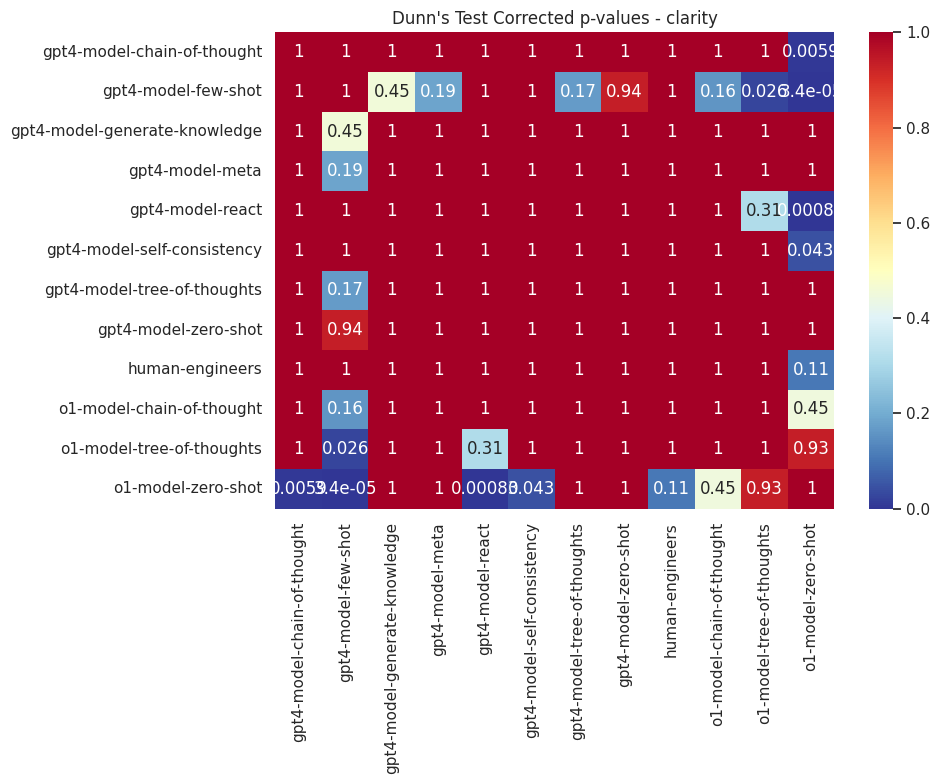


Running Dunn's test for: edge_and_negative_cases_score
                               gpt4-model-chain-of-thought  \
gpt4-model-chain-of-thought                       1.000000   
gpt4-model-few-shot                               0.467723   
gpt4-model-generate-knowledge                     1.000000   
gpt4-model-meta                                   1.000000   
gpt4-model-react                                  1.000000   
gpt4-model-self-consistency                       1.000000   
gpt4-model-tree-of-thoughts                       1.000000   
gpt4-model-zero-shot                              1.000000   
human-engineers                                   1.000000   
o1-model-chain-of-thought                         0.137740   
o1-model-tree-of-thoughts                         0.093014   
o1-model-zero-shot                                0.561761   

                               gpt4-model-few-shot  \
gpt4-model-chain-of-thought           4.677226e-01   
gpt4-model-few-shot          

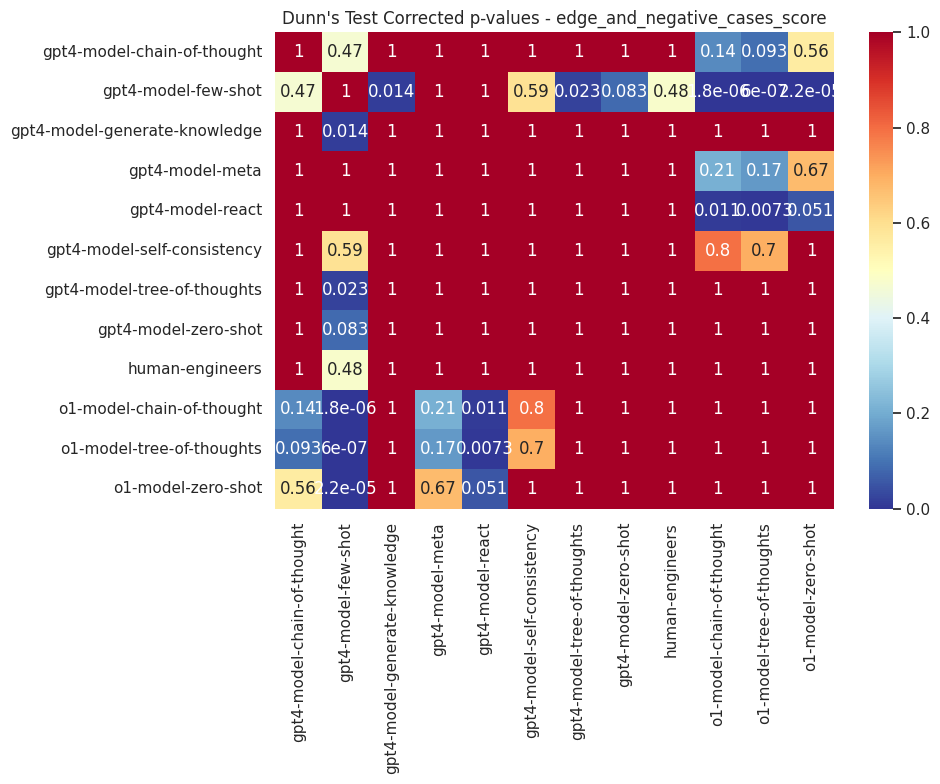


Running Dunn's test for: non_functional_coverage
                               gpt4-model-chain-of-thought  \
gpt4-model-chain-of-thought                       1.000000   
gpt4-model-few-shot                               1.000000   
gpt4-model-generate-knowledge                     1.000000   
gpt4-model-meta                                   1.000000   
gpt4-model-react                                  1.000000   
gpt4-model-self-consistency                       1.000000   
gpt4-model-tree-of-thoughts                       1.000000   
gpt4-model-zero-shot                              1.000000   
human-engineers                                   0.061473   
o1-model-chain-of-thought                         0.003607   
o1-model-tree-of-thoughts                         1.000000   
o1-model-zero-shot                                1.000000   

                               gpt4-model-few-shot  \
gpt4-model-chain-of-thought           1.000000e+00   
gpt4-model-few-shot                

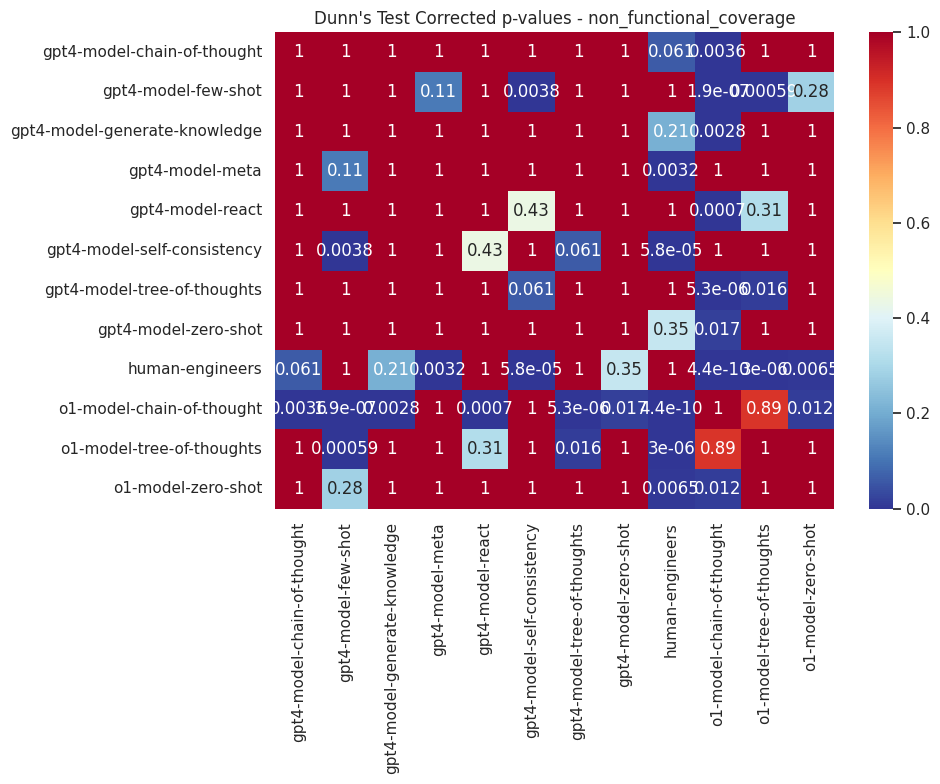


Running Dunn's test for: quality_score
                               gpt4-model-chain-of-thought  \
gpt4-model-chain-of-thought                       1.000000   
gpt4-model-few-shot                               0.114031   
gpt4-model-generate-knowledge                     1.000000   
gpt4-model-meta                                   1.000000   
gpt4-model-react                                  1.000000   
gpt4-model-self-consistency                       1.000000   
gpt4-model-tree-of-thoughts                       1.000000   
gpt4-model-zero-shot                              1.000000   
human-engineers                                   1.000000   
o1-model-chain-of-thought                         0.002148   
o1-model-tree-of-thoughts                         0.187611   
o1-model-zero-shot                                1.000000   

                               gpt4-model-few-shot  \
gpt4-model-chain-of-thought           1.140306e-01   
gpt4-model-few-shot                   1.00000

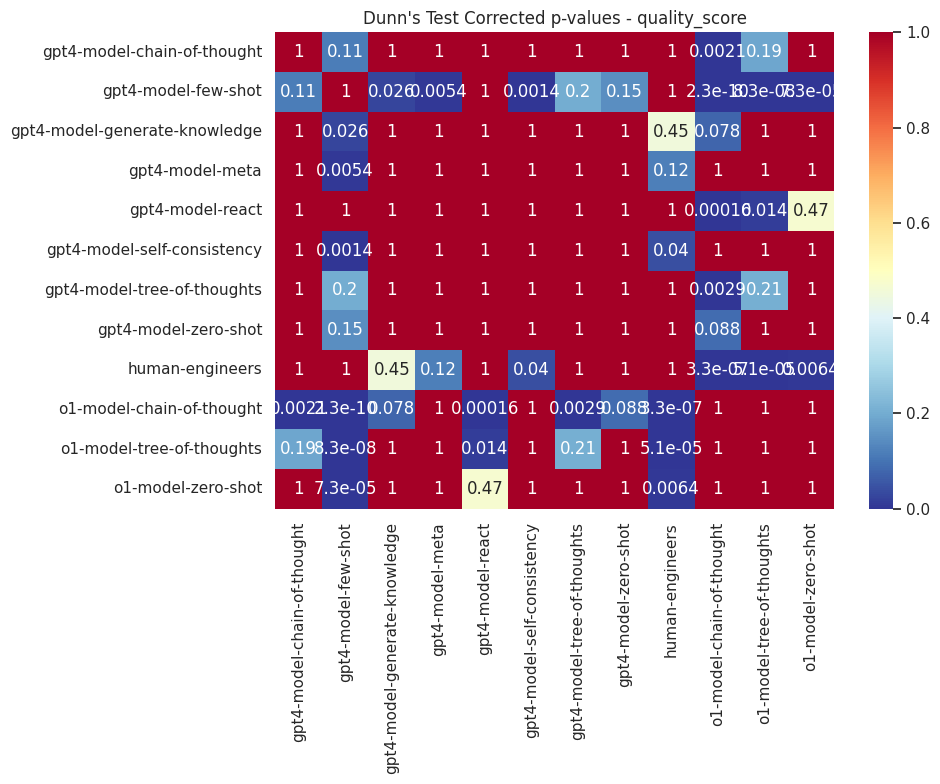

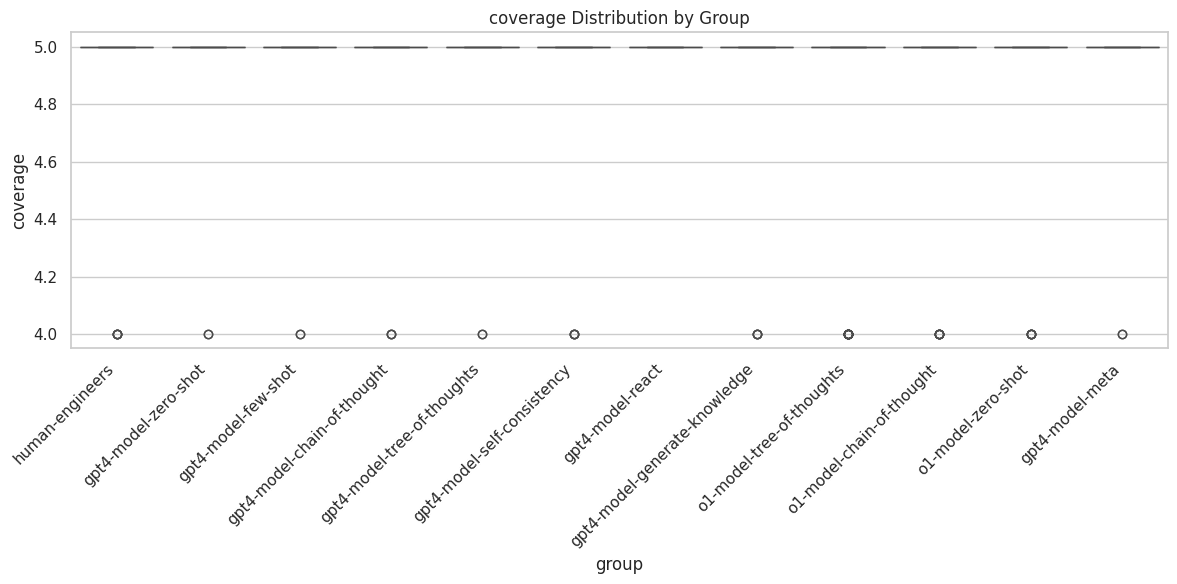

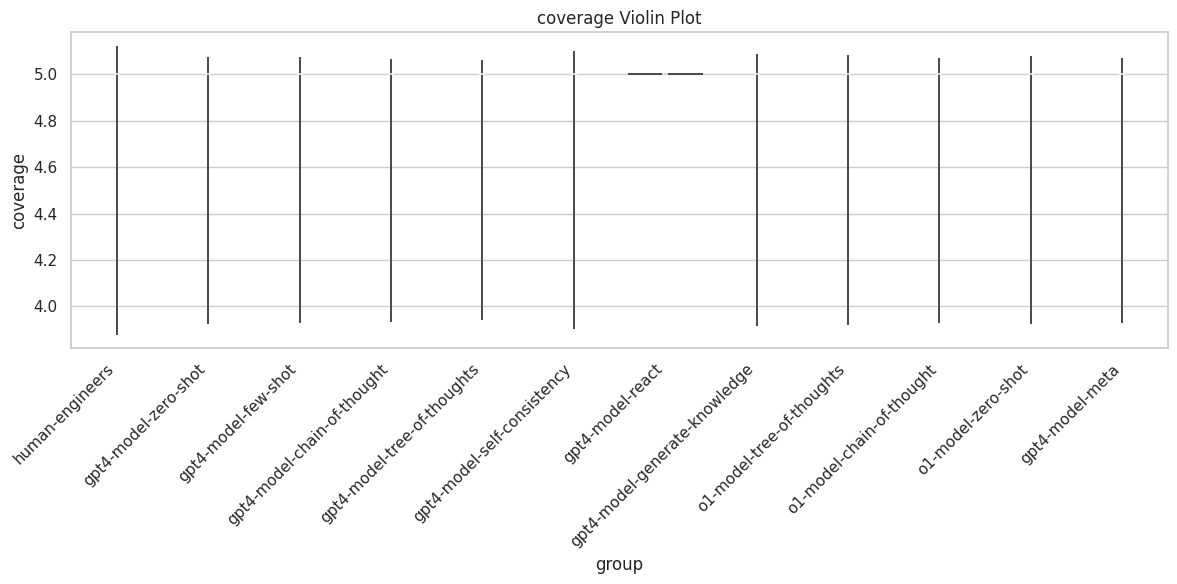

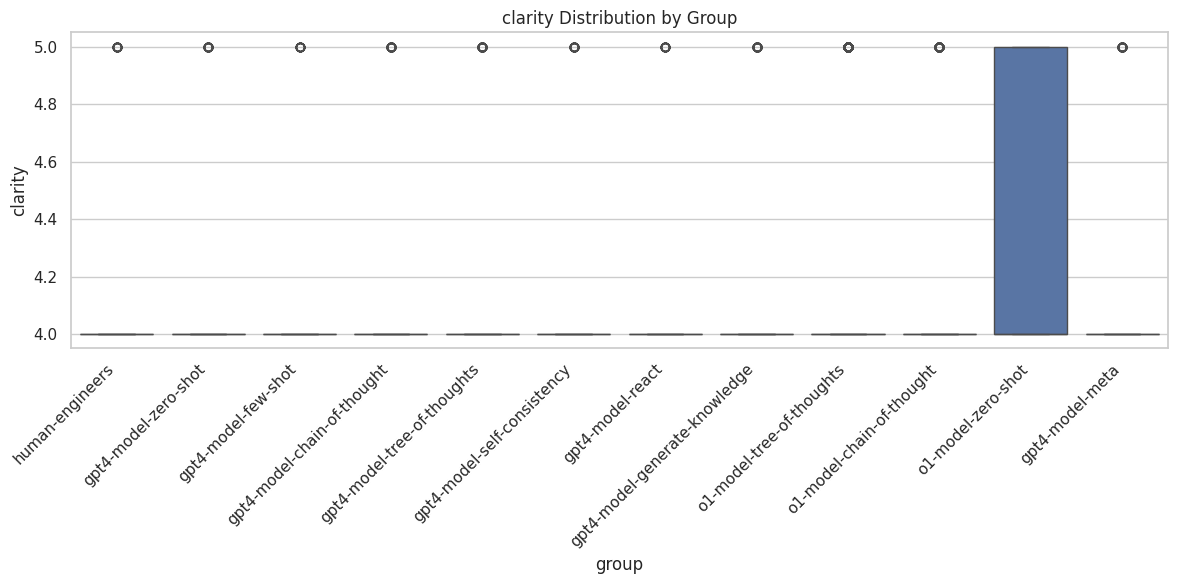

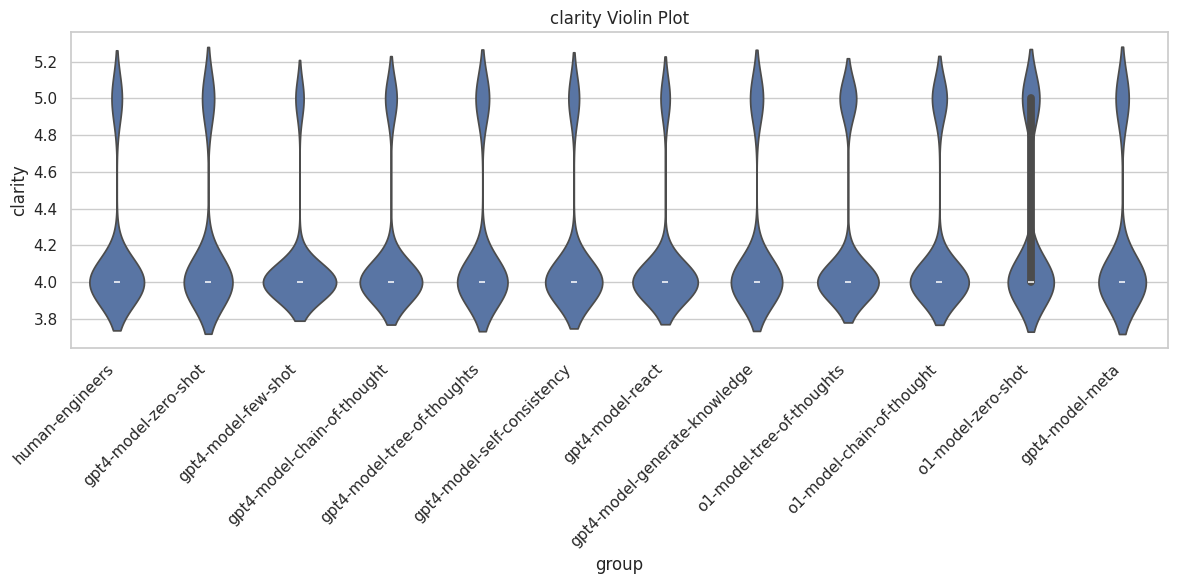

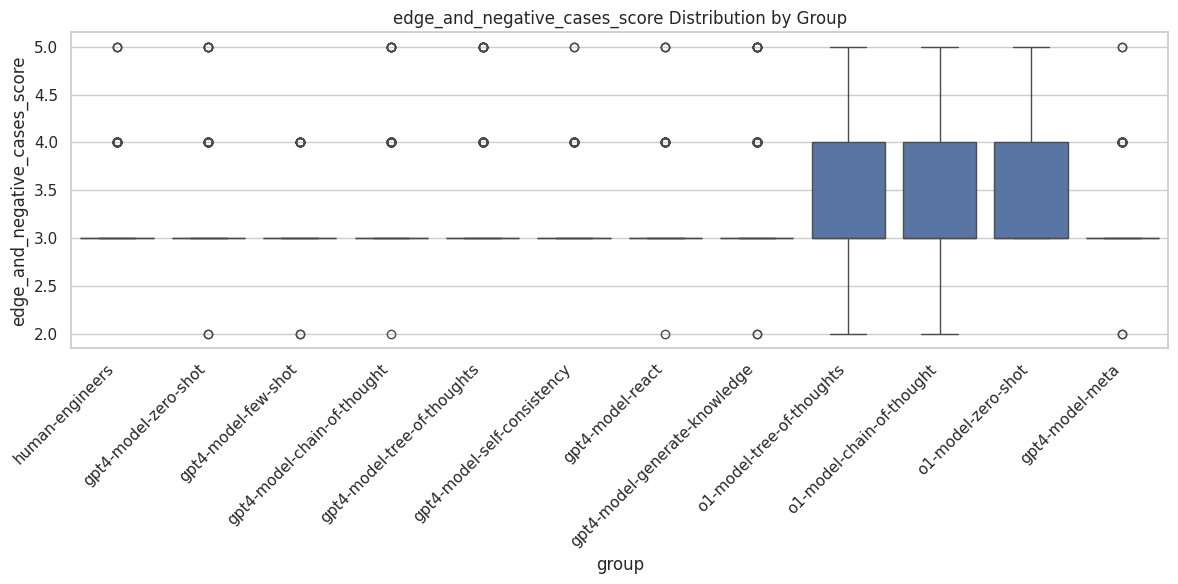

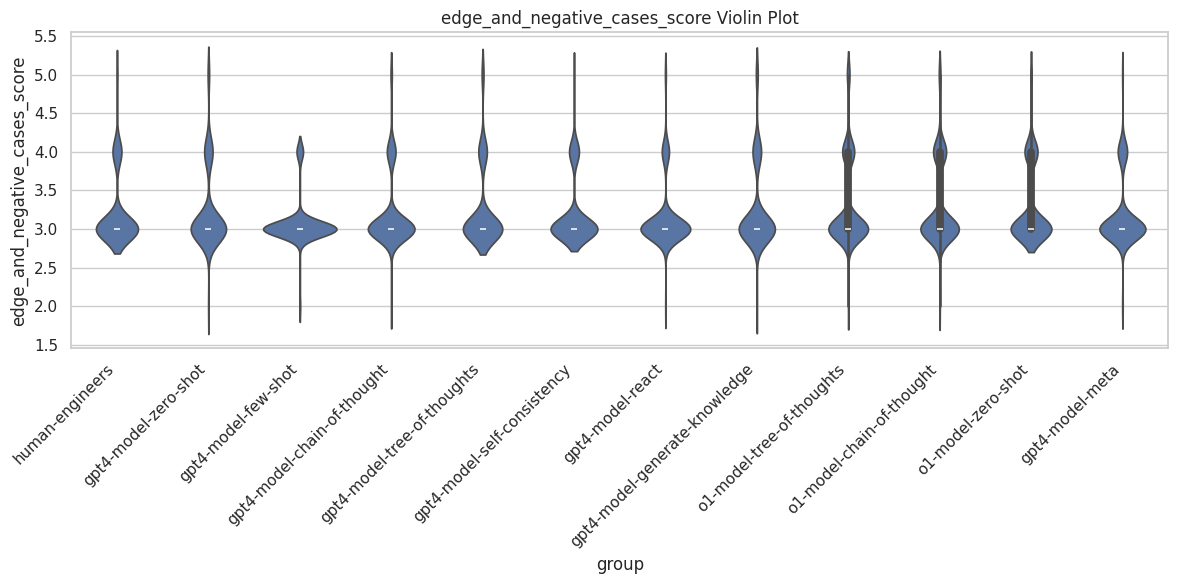

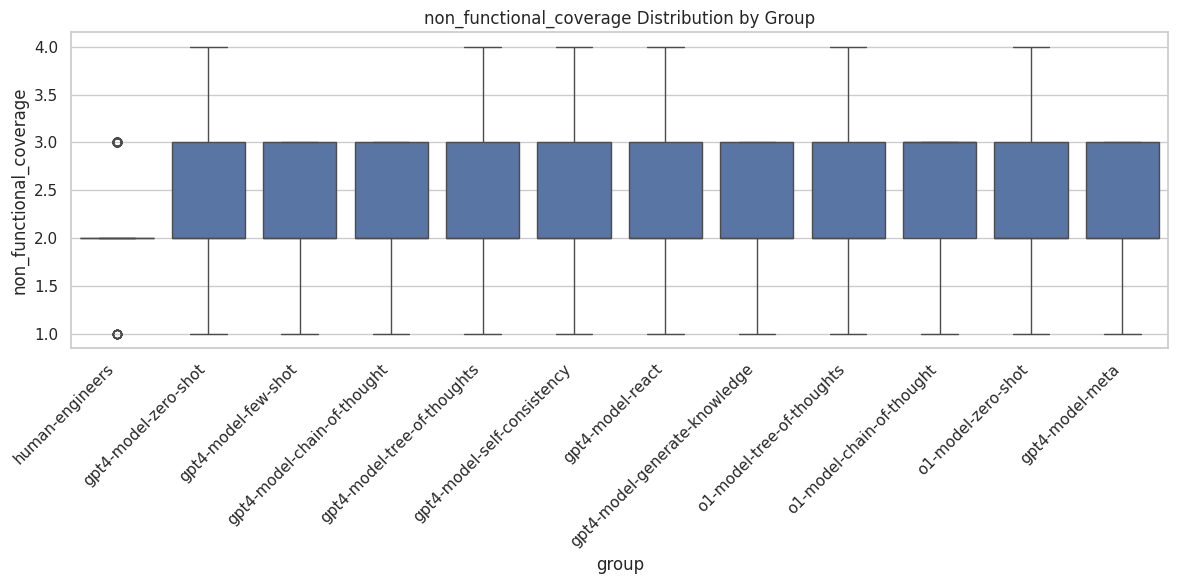

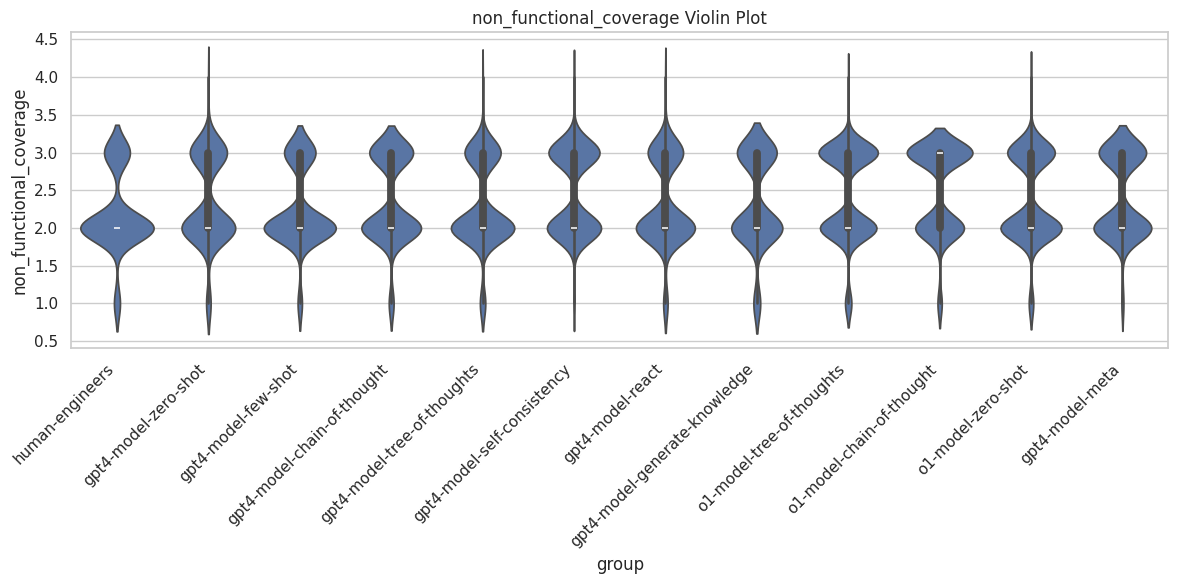

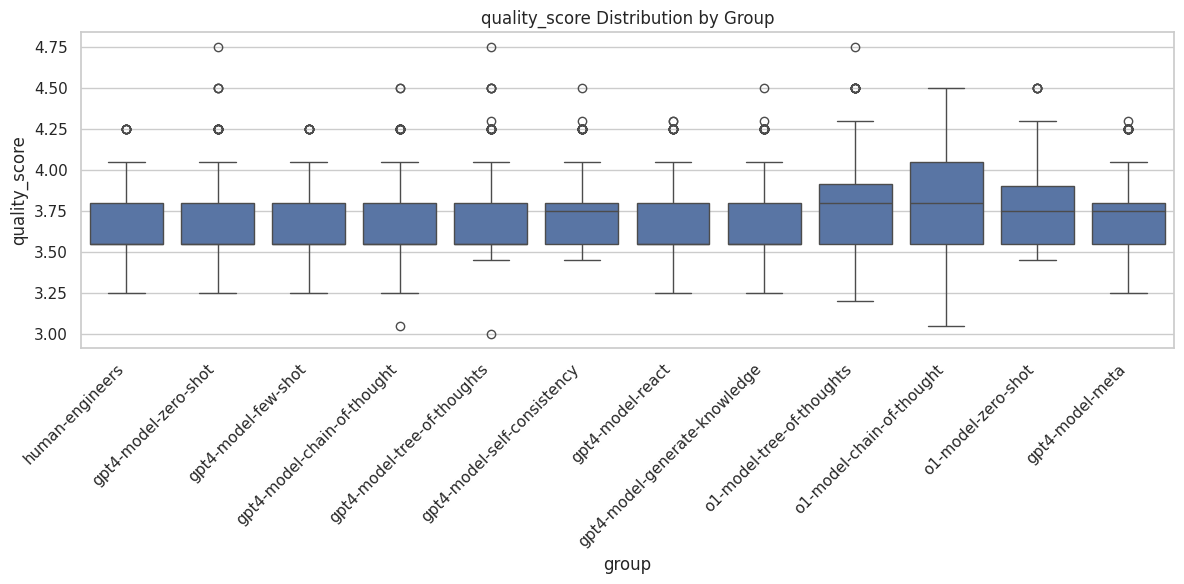

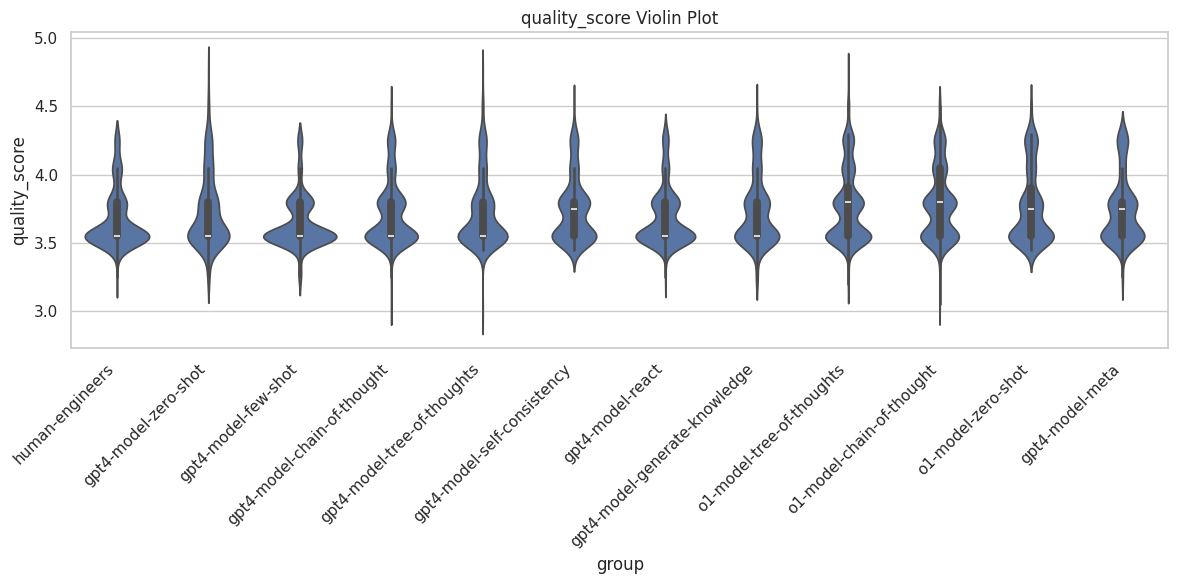


ALL ANALYSIS COMPLETED

Results saved in folder: dunn_test_results

Generated Files:
- descriptive_statistics.csv
- kruskal_wallis_results.csv
- dunn_pairwise_results.csv
- metric-wise Dunn matrix CSV files
- heatmaps
- boxplots
- violin plots
- complete_dunn_report.json


In [17]:
# ============================================================
# Google Colab Script:
# Kruskal-Wallis + Dunn's Post Hoc Test
#
# This script:
# 1. Uploads JSON dataset
# 2. Converts dataset into evaluation format
# 3. Runs Kruskal-Wallis tests
# 4. Runs Dunn's post hoc tests ONLY when Kruskal is significant
# 5. Applies Bonferroni correction
# 6. Creates CSV reports and visualizations
#
# Recommended for:
# Non-normal ordinal/discrete scoring datasets (like yours)
# ============================================================

# ============================================================
# Install Required Libraries
# ============================================================

!pip install scipy seaborn scikit-posthocs --quiet

# ============================================================
# Imports
# ============================================================

import json
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from scipy.stats import kruskal
import scikit_posthocs as sp

# ============================================================
# Upload Dataset
# ============================================================

print("Upload your JSON dataset file now.")

uploaded = files.upload()

uploaded_file = list(uploaded.keys())[0]

with open(uploaded_file, "r", encoding="utf-8") as f:
    raw_dataset = json.load(f)

print(f"\nLoaded Dataset: {uploaded_file}")
print(f"Total Records: {len(raw_dataset)}")

# ============================================================
# Convert Raw Dataset into Evaluation Data
# ============================================================

def format_data_to_evaluations(dataset):

    evaluations = []

    for result in dataset:

        evaluations.append({
            "test_case_id": result["test_case_id"],
            "group": result["group"],

            "coverage":
                result["evaluation"]["coverage"]["score"],

            "clarity":
                result["evaluation"]["clarity"]["score"],

            "edge_and_negative_cases_score":
                result["evaluation"]["edge_and_negative_cases_score"]["score"],

            "non_functional_coverage":
                result["evaluation"]["non_functional_coverage"]["score"],

            "quality_score":
                (
                    0.30 * result["evaluation"]["coverage"]["score"]
                    + 0.20 * result["evaluation"]["clarity"]["score"]
                    + 0.25 * result["evaluation"]["edge_and_negative_cases_score"]["score"]
                    + 0.25 * result["evaluation"]["non_functional_coverage"]["score"]
                )
        })

    return evaluations

evaluations = format_data_to_evaluations(raw_dataset)

df = pd.DataFrame(evaluations)

# ============================================================
# Create Output Directory
# ============================================================

OUTPUT_DIR = "dunn_test_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# Metrics
# ============================================================

metrics = [
    "coverage",
    "clarity",
    "edge_and_negative_cases_score",
    "non_functional_coverage",
    "quality_score"
]

groups = sorted(df["group"].unique())

# ============================================================
# Descriptive Statistics
# ============================================================

print("\n====================================================")
print("Descriptive Statistics")
print("====================================================")

desc_stats = df.groupby("group")[metrics].agg([
    "count",
    "mean",
    "std",
    "median",
    "min",
    "max"
])

print(desc_stats)

desc_stats.to_csv(
    f"{OUTPUT_DIR}/descriptive_statistics.csv"
)

# ============================================================
# Kruskal-Wallis Tests
# ============================================================

print("\n====================================================")
print("Kruskal-Wallis Tests")
print("====================================================")

kruskal_results = []

significant_metrics = []

for metric in metrics:

    grouped_data = [
        df[df["group"] == g][metric].dropna().values
        for g in groups
    ]

    stat, p = kruskal(*grouped_data)

    interpretation = (
        "Significant Difference"
        if p < 0.05
        else "No Significant Difference"
    )

    print(
        f"{metric:<35} "
        f"H={stat:.4f} | "
        f"p={p:.6f} | "
        f"{interpretation}"
    )

    kruskal_results.append({
        "metric": metric,
        "H_statistic": stat,
        "p_value": p,
        "interpretation": interpretation
    })

    if p < 0.05:
        significant_metrics.append(metric)

kruskal_df = pd.DataFrame(kruskal_results)

kruskal_df.to_csv(
    f"{OUTPUT_DIR}/kruskal_wallis_results.csv",
    index=False
)

# ============================================================
# Dunn's Post Hoc Test
# ONLY for Significant Kruskal Metrics
# ============================================================

print("\n====================================================")
print("Dunn's Post Hoc Tests")
print("====================================================")

all_dunn_results = []

for metric in significant_metrics:

    print(f"\nRunning Dunn's test for: {metric}")

    # Bonferroni-adjusted Dunn test
    dunn_matrix = sp.posthoc_dunn(
        df,
        val_col=metric,
        group_col="group",
        p_adjust="bonferroni"
    )

    print(dunn_matrix)

    # Save matrix CSV
    dunn_matrix.to_csv(
        f"{OUTPUT_DIR}/{metric}_dunn_matrix.csv"
    )

    # Convert matrix into pairwise rows
    for row_group in dunn_matrix.index:
        for col_group in dunn_matrix.columns:

            if row_group >= col_group:
                continue

            p_value = dunn_matrix.loc[row_group, col_group]

            all_dunn_results.append({
                "metric": metric,
                "group_1": row_group,
                "group_2": col_group,
                "corrected_p_value": p_value,
                "interpretation":
                    "Significant"
                    if p_value < 0.05
                    else "Not Significant"
            })

    # ========================================================
    # Heatmap Visualization
    # ========================================================

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        dunn_matrix,
        annot=True,
        cmap="RdYlBu_r",
        vmin=0,
        vmax=1
    )

    plt.title(f"Dunn's Test Corrected p-values - {metric}")

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{metric}_dunn_heatmap.png",
        dpi=300
    )

    plt.show()

# ============================================================
# Save Dunn Pairwise Results
# ============================================================

dunn_results_df = pd.DataFrame(all_dunn_results)

dunn_results_df.to_csv(
    f"{OUTPUT_DIR}/dunn_pairwise_results.csv",
    index=False
)

# ============================================================
# Distribution Visualizations
# ============================================================

sns.set(style="whitegrid")

for metric in metrics:

    # Boxplot
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=df,
        x="group",
        y=metric
    )

    plt.xticks(rotation=45, ha="right")

    plt.title(f"{metric} Distribution by Group")

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{metric}_boxplot.png",
        dpi=300
    )

    plt.show()

    # Violin Plot
    plt.figure(figsize=(12, 6))

    sns.violinplot(
        data=df,
        x="group",
        y=metric,
        inner="box"
    )

    plt.xticks(rotation=45, ha="right")

    plt.title(f"{metric} Violin Plot")

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{metric}_violin.png",
        dpi=300
    )

    plt.show()

# ============================================================
# Save Combined JSON Report
# ============================================================

combined_report = {
    "kruskal_wallis_results":
        kruskal_df.to_dict(orient="records"),

    "dunn_posthoc_results":
        dunn_results_df.to_dict(orient="records")
}

with open(
    f"{OUTPUT_DIR}/complete_dunn_report.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(combined_report, f, indent=4)

# ============================================================
# Completion Message
# ============================================================

print("\n====================================================")
print("ALL ANALYSIS COMPLETED")
print("====================================================")

print(f"\nResults saved in folder: {OUTPUT_DIR}")

print("\nGenerated Files:")
print("- descriptive_statistics.csv")
print("- kruskal_wallis_results.csv")
print("- dunn_pairwise_results.csv")
print("- metric-wise Dunn matrix CSV files")
print("- heatmaps")
print("- boxplots")
print("- violin plots")
print("- complete_dunn_report.json")

## Download & Delete Results

In [18]:
import shutil
import os
from google.colab import files

# Define the directory to zip and the output filename
folder_to_zip = '/content/dunn_test_results'
output_zip_name = 'dunn_test_results_archive'

# Check if the folder exists
if os.path.exists(folder_to_zip):
    # Create the zip archive
    shutil.make_archive(output_zip_name, 'zip', folder_to_zip)
    print(f"Successfully created '{output_zip_name}.zip'")

    # Download the created zip file
    files.download(f'{output_zip_name}.zip')
    print(f"Download of '{output_zip_name}.zip' initiated.")

    # Delete the original folder after initiating download
    shutil.rmtree(folder_to_zip)
    print(f"The folder '{folder_to_zip}' has been deleted.")
else:
    print(f"Error: The folder '{folder_to_zip}' does not exist.")

Successfully created 'dunn_test_results_archive.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download of 'dunn_test_results_archive.zip' initiated.
The folder '/content/dunn_test_results' has been deleted.


# Comment 2 - Redundency and Similarity Test using TF-IDF

In [19]:
 # ============================================================
# REVIEWER 5 / COMMENT 2 RESPONSE SCRIPT
# Lightweight redundancy + diversity analysis for structured
# software test cases in Google Colab
# ============================================================
#
# What this script does:
# - Upload a JSON file directly in Colab
# - Parse structured test cases like your sample dataset
# - Concatenate key test-case fields into one lexical text
# - Compute exact duplicate rates
# - Compute TF-IDF cosine similarity (no embeddings)
# - Compute manual token-based Jaccard similarity
# - Compare human-engineered vs generated test cases
# - Produce CSVs, plots, and a text report
# - Generate reviewer-friendly interpretation lines
#
# Designed to directly support rebuttal / revision text for:
# "Quantity gains may reflect repetition unless diversity is shown."
#
# ============================================================

# ----------------------------
# 1) Install dependencies
# ----------------------------
!pip -q install pandas numpy scikit-learn matplotlib

# ----------------------------
# 2) Imports
# ----------------------------
import os
import json
import re
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ----------------------------
# 3) Configuration
# ----------------------------
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Dataset field names for your sample JSON
GROUP_FIELD = "group"
MODULE_FIELD = "test_module"
FEATURE_FIELD = "test_feature"

TEXT_FIELDS = [
    "software_name",
    "software_desc",
    "test_module",
    "test_feature",
    "test_case_title",
    "test_case_description",
    "pre_conditions",
    "test_steps",
    "test_data",
    "expected_outcome",
    "severity_status",
]

# Preprocessing options
LOWERCASE_TEXT = True
NORMALIZE_WHITESPACE = True
REMOVE_PUNCTUATION = False

# Similarity settings
TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MAX_FEATURES = 12000
NEAR_DUPLICATE_THRESHOLD = 0.85
MODERATE_OVERLAP_THRESHOLD = 0.70

# Output / display
PREVIEW_CHARS = 140

# ----------------------------
# 4) Helper functions
# ----------------------------
def clean_text(text):
    """Basic lexical normalization."""
    if text is None:
        return ""
    s = str(text)
    if LOWERCASE_TEXT:
        s = s.lower()
    if REMOVE_PUNCTUATION:
        s = re.sub(r"[^\w\s]", " ", s)
    if NORMALIZE_WHITESPACE:
        s = re.sub(r"\s+", " ", s).strip()
    return s

def preview_text(text, length=PREVIEW_CHARS):
    """Short preview for pairwise reporting."""
    s = re.sub(r"\s+", " ", str(text)).strip()
    return s if len(s) <= length else s[: length - 3] + "..."

def token_set(text):
    """Manual tokenization for Jaccard similarity."""
    return set(re.findall(r"\b\w+\b", str(text).lower()))

def jaccard_similarity(a, b):
    """Manual token-based Jaccard similarity."""
    if not a and not b:
        return 0.0
    union = a | b
    if not union:
        return 0.0
    return len(a & b) / len(union)

def extract_records(obj):
    """
    Accept:
    - list of records
    - dict containing a list under common keys
    - dict with a nested list value
    """
    if isinstance(obj, list):
        return obj

    if isinstance(obj, dict):
        common_keys = ["data", "items", "records", "results", "test_cases", "cases", "outputs", "examples"]
        for k in common_keys:
            if k in obj and isinstance(obj[k], list):
                return obj[k]
        for v in obj.values():
            if isinstance(v, list):
                return v
        for v in obj.values():
            if isinstance(v, dict):
                for vv in v.values():
                    if isinstance(vv, list):
                        return vv

    raise ValueError("Unsupported JSON structure. Expected a list of objects or a dict containing a list.")

def get_str_field(record, field_name, default=""):
    """Safe field fetch."""
    val = record.get(field_name, default)
    return "" if val is None else str(val)

def build_full_test_case_text(record):
    """
    Structured concatenation of all relevant fields.

    This is the key fix for your dataset:
    the test case is not contained in a single text field.
    We merge title, description, steps, data, expected outcome, etc.
    """
    parts = []
    for field in TEXT_FIELDS:
        val = record.get(field, "")
        if val is None:
            continue
        val = str(val).strip()
        if val:
            parts.append(val)
    return "\n".join(parts)

def make_group_label(record):
    """
    Use the provided 'group' field as the primary comparison axis.
    This is crucial for comparing human-engineered vs generated cases.
    """
    group = get_str_field(record, GROUP_FIELD, "unknown_group").strip()
    return group if group else "unknown_group"

def safe_sort_desc(df, col):
    if df.empty or col not in df.columns:
        return df
    return df.sort_values(col, ascending=False).reset_index(drop=True)

# ----------------------------
# 5) Upload JSON file
# ----------------------------
print("=" * 80)
print("UPLOAD YOUR JSON FILE")
print("=" * 80)

uploaded = files.upload()
if not uploaded:
    raise ValueError("No file uploaded.")

json_filename = next(iter(uploaded.keys()))
raw_bytes = uploaded[json_filename]
raw_text = raw_bytes.decode("utf-8", errors="replace")
json_obj = json.loads(raw_text)
records = extract_records(json_obj)

print(f"\nLoaded file: {json_filename}")
print(f"Total raw records: {len(records)}")

# ----------------------------
# 6) Build analysis dataframe
# ----------------------------
rows = []
for idx, record in enumerate(records):
    if not isinstance(record, dict):
        continue

    group_name = make_group_label(record)

    module_name = get_str_field(record, MODULE_FIELD, "unknown_module").strip()
    feature_name = get_str_field(record, FEATURE_FIELD, "unknown_feature").strip()

    full_text = build_full_test_case_text(record)
    cleaned_text = clean_text(full_text)

    if not cleaned_text:
        continue

    rows.append({
        "row_id": idx,
        "group": group_name,
        "module": module_name if module_name else "unknown_module",
        "feature": feature_name if feature_name else "unknown_feature",
        "test_case_id": get_str_field(record, "test_case_id", f"row_{idx}"),
        "test_case_title": get_str_field(record, "test_case_title", ""),
        "severity_status": get_str_field(record, "severity_status", ""),
        "raw_text": full_text,
        "clean_text": cleaned_text,
        "token_count": len(re.findall(r"\b\w+\b", cleaned_text)),
        "char_count": len(cleaned_text),
    })

df = pd.DataFrame(rows)

if not df.empty:
    df = df[df["clean_text"].astype(str).str.strip() != ""].copy()
    df.reset_index(drop=True, inplace=True)
else:
    df = pd.DataFrame(columns=[
        "row_id", "group", "module", "feature", "test_case_id", "test_case_title",
        "severity_status", "raw_text", "clean_text", "token_count", "char_count"
    ])

print("\nCleaned Dataset Preview:")
print(df.head(5).to_string(index=False) if not df.empty else "Empty DataFrame")

print("\nDataset Statistics:")
print(f"Valid test cases: {len(df)}")
print(f"Unique groups: {df['group'].nunique() if not df.empty else 0}")
print(f"Unique modules: {df['module'].nunique() if not df.empty else 0}")
print(f"Unique features: {df['feature'].nunique() if not df.empty else 0}")

df.to_csv(os.path.join(RESULTS_DIR, "cleaned_test_cases.csv"), index=False)

if df.empty:
    print("\nNo valid test cases extracted. Check the JSON structure and field names.")
    raise SystemExit

# Add a human-vs-generated label for reviewer-oriented interpretation
df["origin_type"] = np.where(df["group"].astype(str).str.lower().eq("human-engineers"), "human", "generated")

# ----------------------------
# 7) Exact duplicate analysis
# ----------------------------
def exact_duplicate_summary(dataframe, group_col, group_label):
    cols = [
        "group_type", "group_name", "total_test_cases",
        "unique_test_cases", "exact_duplicate_count",
        "duplicate_percentage"
    ]
    if dataframe.empty or group_col not in dataframe.columns:
        return pd.DataFrame(columns=cols)

    out_rows = []
    for gname, sub in dataframe.groupby(group_col, dropna=False):
        total = len(sub)
        unique = sub["clean_text"].nunique()
        dup_count = total - unique
        dup_pct = (dup_count / total * 100.0) if total else 0.0
        out_rows.append({
            "group_type": group_label,
            "group_name": str(gname),
            "total_test_cases": int(total),
            "unique_test_cases": int(unique),
            "exact_duplicate_count": int(dup_count),
            "duplicate_percentage": round(float(dup_pct), 2),
        })

    out_df = pd.DataFrame(out_rows, columns=cols)
    if not out_df.empty:
        out_df = out_df.sort_values(["duplicate_percentage", "total_test_cases"], ascending=[False, False]).reset_index(drop=True)
    return out_df

exact_by_group_df = exact_duplicate_summary(df, "group", "group")
exact_by_module_df = exact_duplicate_summary(df, "module", "module")
exact_by_feature_df = exact_duplicate_summary(df, "feature", "feature")

print("\n" + "=" * 80)
print("EXACT DUPLICATE ANALYSIS BY GROUP")
print("=" * 80)
print(exact_by_group_df.to_string(index=False) if not exact_by_group_df.empty else "No rows")

print("\n" + "=" * 80)
print("EXACT DUPLICATE ANALYSIS BY MODULE")
print("=" * 80)
print(exact_by_module_df.to_string(index=False) if not exact_by_module_df.empty else "No rows")

print("\n" + "=" * 80)
print("EXACT DUPLICATE ANALYSIS BY FEATURE")
print("=" * 80)
print(exact_by_feature_df.to_string(index=False) if not exact_by_feature_df.empty else "No rows")

exact_by_group_df.to_csv(os.path.join(RESULTS_DIR, "exact_duplicate_by_group.csv"), index=False)
exact_by_module_df.to_csv(os.path.join(RESULTS_DIR, "exact_duplicate_by_module.csv"), index=False)
exact_by_feature_df.to_csv(os.path.join(RESULTS_DIR, "exact_duplicate_by_feature.csv"), index=False)

# Human vs generated exact duplicate summary
human_df = df[df["origin_type"] == "human"].copy()
gen_df = df[df["origin_type"] == "generated"].copy()

exact_human_gen_df = pd.DataFrame([
    {
        "subset": "human",
        "total_test_cases": len(human_df),
        "unique_test_cases": human_df["clean_text"].nunique() if not human_df.empty else 0,
        "exact_duplicate_count": len(human_df) - human_df["clean_text"].nunique() if not human_df.empty else 0,
        "duplicate_percentage": round(((len(human_df) - human_df["clean_text"].nunique()) / len(human_df) * 100.0), 2) if len(human_df) else 0.0
    },
    {
        "subset": "generated",
        "total_test_cases": len(gen_df),
        "unique_test_cases": gen_df["clean_text"].nunique() if not gen_df.empty else 0,
        "exact_duplicate_count": len(gen_df) - gen_df["clean_text"].nunique() if not gen_df.empty else 0,
        "duplicate_percentage": round(((len(gen_df) - gen_df["clean_text"].nunique()) / len(gen_df) * 100.0), 2) if len(gen_df) else 0.0
    }
])

print("\n" + "=" * 80)
print("HUMAN VS GENERATED EXACT DUPLICATE SUMMARY")
print("=" * 80)
print(exact_human_gen_df.to_string(index=False))

exact_human_gen_df.to_csv(os.path.join(RESULTS_DIR, "exact_duplicate_human_vs_generated.csv"), index=False)

# ----------------------------
# 8) TF-IDF cosine similarity
# ----------------------------
def tfidf_similarity_metrics(text_list):
    n = len(text_list)
    empty_summary = {
        "total_test_cases": n,
        "pair_count": 0,
        "average_similarity": 0.0,
        "maximum_similarity": 0.0,
        "redundancy_ratio": 0.0,
        "diversity_ratio": 1.0,
        "near_duplicate_count": 0,
        "near_duplicate_ratio": 0.0,
        "moderate_overlap_count": 0,
        "moderate_overlap_ratio": 0.0,
    }

    if n <= 1:
        return None, empty_summary, np.array([]), np.array([]), np.array([])

    vectorizer = TfidfVectorizer(
        ngram_range=TFIDF_NGRAM_RANGE,
        max_features=TFIDF_MAX_FEATURES,
        lowercase=False
    )
    X = vectorizer.fit_transform(text_list)
    sim = cosine_similarity(X, X, dense_output=False)

    coo = sim.tocoo()
    mask = coo.row < coo.col
    upper_rows = coo.row[mask]
    upper_cols = coo.col[mask]
    upper_vals = coo.data[mask]

    pair_count = n * (n - 1) / 2.0
    total_sum = float(sim.sum())
    upper_sum = (total_sum - n) / 2.0

    avg_sim = upper_sum / pair_count if pair_count else 0.0
    max_sim = float(upper_vals.max()) if len(upper_vals) else 0.0

    near_dup = int(np.sum(upper_vals > NEAR_DUPLICATE_THRESHOLD))
    moderate = int(np.sum(upper_vals > MODERATE_OVERLAP_THRESHOLD))

    summary = {
        "total_test_cases": int(n),
        "pair_count": int(pair_count),
        "average_similarity": round(float(avg_sim), 6),
        "maximum_similarity": round(float(max_sim), 6),
        "redundancy_ratio": round(float(avg_sim), 6),
        "diversity_ratio": round(float(1.0 - avg_sim), 6),
        "near_duplicate_count": int(near_dup),
        "near_duplicate_ratio": round(float(near_dup / pair_count), 6) if pair_count else 0.0,
        "moderate_overlap_count": int(moderate),
        "moderate_overlap_ratio": round(float(moderate / pair_count), 6) if pair_count else 0.0,
    }
    return sim, summary, upper_rows, upper_cols, upper_vals

sim_all, tfidf_overall_summary, upper_rows, upper_cols, upper_vals = tfidf_similarity_metrics(df["clean_text"].tolist())
tfidf_overall_df = pd.DataFrame([tfidf_overall_summary])

print("\n" + "=" * 80)
print("OVERALL TF-IDF COSINE SIMILARITY")
print("=" * 80)
print(tfidf_overall_df.to_string(index=False))

tfidf_overall_df.to_csv(os.path.join(RESULTS_DIR, "tfidf_overall_summary.csv"), index=False)

# Pairwise cosine similarity table
pair_rows = []
for r, c, v in zip(upper_rows, upper_cols, upper_vals):
    pair_rows.append({
        "index_1": int(r),
        "index_2": int(c),
        "group_1": df.loc[r, "group"],
        "module_1": df.loc[r, "module"],
        "title_1": df.loc[r, "test_case_title"],
        "preview_1": preview_text(df.loc[r, "clean_text"]),
        "group_2": df.loc[c, "group"],
        "module_2": df.loc[c, "module"],
        "title_2": df.loc[c, "test_case_title"],
        "preview_2": preview_text(df.loc[c, "clean_text"]),
        "cosine_similarity": round(float(v), 6),
    })

pairwise_cosine_df = pd.DataFrame(pair_rows)
if not pairwise_cosine_df.empty:
    pairwise_cosine_df = pairwise_cosine_df.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("TOP 20 MOST SIMILAR TEST CASE PAIRS (COSINE)")
print("=" * 80)
if pairwise_cosine_df.empty:
    print("No non-zero similar pairs found.")
else:
    print(pairwise_cosine_df.head(20)[[
        "cosine_similarity", "group_1", "module_1", "title_1", "preview_1",
        "group_2", "module_2", "title_2", "preview_2"
    ]].to_string(index=False))

pairwise_cosine_df.to_csv(os.path.join(RESULTS_DIR, "all_pairwise_cosine_similarities.csv"), index=False)
pairwise_cosine_df.head(20).to_csv(os.path.join(RESULTS_DIR, "top_20_similar_pairs.csv"), index=False)

# ----------------------------
# 9) Jaccard similarity
# ----------------------------
def jaccard_metrics(text_list):
    n = len(text_list)
    if n <= 1:
        return {
            "total_test_cases": n,
            "pair_count": 0,
            "average_jaccard_similarity": 0.0,
            "maximum_jaccard_similarity": 0.0
        }, pd.DataFrame(columns=["index_1", "index_2", "jaccard_similarity"])

    sets = [token_set(t) for t in text_list]
    values = []
    rows = []

    for i, j in itertools.combinations(range(n), 2):
        sim = jaccard_similarity(sets[i], sets[j])
        values.append(sim)
        rows.append({
            "index_1": i,
            "index_2": j,
            "jaccard_similarity": round(float(sim), 6)
        })

    arr = np.array(values, dtype=float) if values else np.array([])
    summary = {
        "total_test_cases": int(n),
        "pair_count": int(n * (n - 1) / 2),
        "average_jaccard_similarity": round(float(arr.mean()), 6) if len(arr) else 0.0,
        "maximum_jaccard_similarity": round(float(arr.max()), 6) if len(arr) else 0.0
    }

    pair_df = pd.DataFrame(rows)
    if not pair_df.empty:
        pair_df = pair_df.sort_values("jaccard_similarity", ascending=False).reset_index(drop=True)
    return summary, pair_df

jaccard_overall_summary, jaccard_pair_df = jaccard_metrics(df["clean_text"].tolist())
jaccard_overall_df = pd.DataFrame([jaccard_overall_summary])

print("\n" + "=" * 80)
print("OVERALL JACCARD SIMILARITY")
print("=" * 80)
print(jaccard_overall_df.to_string(index=False))

jaccard_overall_df.to_csv(os.path.join(RESULTS_DIR, "jaccard_overall_summary.csv"), index=False)
jaccard_pair_df.to_csv(os.path.join(RESULTS_DIR, "all_pairwise_jaccard_similarities.csv"), index=False)

# ----------------------------
# 10) Group-level summaries
# ----------------------------
def group_tfidf_summary(dataframe, group_col):
    rows = []
    if dataframe.empty:
        return pd.DataFrame()

    for gname, sub in dataframe.groupby(group_col, dropna=False):
        _, summary, _, _, _ = tfidf_similarity_metrics(sub["clean_text"].tolist())
        rows.append({"group_name": str(gname), **summary})
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values("redundancy_ratio", ascending=False).reset_index(drop=True)
    return out

def group_jaccard_summary(dataframe, group_col):
    rows = []
    if dataframe.empty:
        return pd.DataFrame()

    for gname, sub in dataframe.groupby(group_col, dropna=False):
        summary, _ = jaccard_metrics(sub["clean_text"].tolist())
        rows.append({"group_name": str(gname), **summary})
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values("average_jaccard_similarity", ascending=False).reset_index(drop=True)
    return out

tfidf_by_group_df = group_tfidf_summary(df, "group")
tfidf_by_module_df = group_tfidf_summary(df, "module")
tfidf_by_feature_df = group_tfidf_summary(df, "feature")

jaccard_by_group_df = group_jaccard_summary(df, "group")
jaccard_by_module_df = group_jaccard_summary(df, "module")
jaccard_by_feature_df = group_jaccard_summary(df, "feature")

print("\n" + "=" * 80)
print("TF-IDF SUMMARY BY GROUP")
print("=" * 80)
print(tfidf_by_group_df.to_string(index=False) if not tfidf_by_group_df.empty else "No rows")

print("\n" + "=" * 80)
print("TF-IDF SUMMARY BY MODULE")
print("=" * 80)
print(tfidf_by_module_df.to_string(index=False) if not tfidf_by_module_df.empty else "No rows")

print("\n" + "=" * 80)
print("JACCARD SUMMARY BY GROUP")
print("=" * 80)
print(jaccard_by_group_df.to_string(index=False) if not jaccard_by_group_df.empty else "No rows")

tfidf_by_group_df.to_csv(os.path.join(RESULTS_DIR, "tfidf_by_group.csv"), index=False)
tfidf_by_module_df.to_csv(os.path.join(RESULTS_DIR, "tfidf_by_module.csv"), index=False)
tfidf_by_feature_df.to_csv(os.path.join(RESULTS_DIR, "tfidf_by_feature.csv"), index=False)

jaccard_by_group_df.to_csv(os.path.join(RESULTS_DIR, "jaccard_by_group.csv"), index=False)
jaccard_by_module_df.to_csv(os.path.join(RESULTS_DIR, "jaccard_by_module.csv"), index=False)
jaccard_by_feature_df.to_csv(os.path.join(RESULTS_DIR, "jaccard_by_feature.csv"), index=False)

# Human vs generated group-level summary
human_generated_group_summary = pd.DataFrame([
    {
        "subset": "human",
        "total_test_cases": len(human_df),
        "average_similarity": tfidf_similarity_metrics(human_df["clean_text"].tolist())[1]["average_similarity"] if not human_df.empty else 0.0,
        "redundancy_ratio": tfidf_similarity_metrics(human_df["clean_text"].tolist())[1]["redundancy_ratio"] if not human_df.empty else 0.0,
        "diversity_ratio": tfidf_similarity_metrics(human_df["clean_text"].tolist())[1]["diversity_ratio"] if not human_df.empty else 1.0,
        "average_jaccard_similarity": jaccard_metrics(human_df["clean_text"].tolist())[0]["average_jaccard_similarity"] if not human_df.empty else 0.0,
    },
    {
        "subset": "generated",
        "total_test_cases": len(gen_df),
        "average_similarity": tfidf_similarity_metrics(gen_df["clean_text"].tolist())[1]["average_similarity"] if not gen_df.empty else 0.0,
        "redundancy_ratio": tfidf_similarity_metrics(gen_df["clean_text"].tolist())[1]["redundancy_ratio"] if not gen_df.empty else 0.0,
        "diversity_ratio": tfidf_similarity_metrics(gen_df["clean_text"].tolist())[1]["diversity_ratio"] if not gen_df.empty else 1.0,
        "average_jaccard_similarity": jaccard_metrics(gen_df["clean_text"].tolist())[0]["average_jaccard_similarity"] if not gen_df.empty else 0.0,
    }
])

print("\n" + "=" * 80)
print("HUMAN VS GENERATED SUMMARY")
print("=" * 80)
print(human_generated_group_summary.to_string(index=False))

human_generated_group_summary.to_csv(os.path.join(RESULTS_DIR, "human_vs_generated_summary.csv"), index=False)

# ----------------------------
# 11) Visualizations
# ----------------------------
def save_histogram(values, title, xlabel, path, bins=20):
    plt.figure(figsize=(10, 6))
    if len(values):
        plt.hist(values, bins=bins)
    else:
        plt.hist([0.0], bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()

def save_barplot(df_plot, x_col, y_col, title, xlabel, ylabel, path):
    plt.figure(figsize=(12, 6))
    plt.bar(df_plot[x_col].astype(str), df_plot[y_col].astype(float))
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()

# Histogram of cosine similarities
cosine_hist_path = os.path.join(RESULTS_DIR, "cosine_similarity_histogram.png")
save_histogram(
    upper_vals if len(upper_vals) else np.array([0.0]),
    "Histogram of TF-IDF Cosine Similarities",
    "Cosine similarity",
    cosine_hist_path,
    bins=20
)

# Bar charts by group
if not tfidf_by_group_df.empty:
    redundancy_group_path = os.path.join(RESULTS_DIR, "redundancy_ratio_by_group.png")
    diversity_group_path = os.path.join(RESULTS_DIR, "diversity_ratio_by_group.png")
    save_barplot(
        tfidf_by_group_df.sort_values("redundancy_ratio", ascending=False),
        "group_name",
        "redundancy_ratio",
        "Redundancy Ratio by Group",
        "Group",
        "Redundancy ratio",
        redundancy_group_path
    )
    save_barplot(
        tfidf_by_group_df.sort_values("diversity_ratio", ascending=False),
        "group_name",
        "diversity_ratio",
        "Diversity Ratio by Group",
        "Group",
        "Diversity ratio",
        diversity_group_path
    )

# Bar charts for human vs generated
hg_path = os.path.join(RESULTS_DIR, "human_vs_generated_redundancy.png")
plt.figure(figsize=(8, 5))
plt.bar(human_generated_group_summary["subset"], human_generated_group_summary["redundancy_ratio"])
plt.title("Redundancy Ratio: Human vs Generated")
plt.xlabel("Subset")
plt.ylabel("Redundancy ratio")
plt.tight_layout()
plt.savefig(hg_path, dpi=200)
plt.close()

hg_div_path = os.path.join(RESULTS_DIR, "human_vs_generated_diversity.png")
plt.figure(figsize=(8, 5))
plt.bar(human_generated_group_summary["subset"], human_generated_group_summary["diversity_ratio"])
plt.title("Diversity Ratio: Human vs Generated")
plt.xlabel("Subset")
plt.ylabel("Diversity ratio")
plt.tight_layout()
plt.savefig(hg_div_path, dpi=200)
plt.close()

print("\nSaved plots to results/")

# ----------------------------
# 12) Interpretation for reviewer response
# ----------------------------
interpretation_lines = []

overall_red = float(tfidf_overall_summary["redundancy_ratio"])

if overall_red < 0.10:
    interpretation_lines.append("Overall lexical redundancy was low.")
elif overall_red < 0.25:
    interpretation_lines.append("Overall lexical redundancy was moderate.")
else:
    interpretation_lines.append("Overall lexical redundancy was high.")

if not human_generated_group_summary.empty:
    human_red = float(human_generated_group_summary.loc[human_generated_group_summary["subset"] == "human", "redundancy_ratio"].iloc[0])
    gen_red = float(human_generated_group_summary.loc[human_generated_group_summary["subset"] == "generated", "redundancy_ratio"].iloc[0])

    if gen_red > human_red:
        interpretation_lines.append("Generated test cases showed higher lexical overlap than human-engineered cases.")
    else:
        interpretation_lines.append("Generated test cases did not show higher lexical overlap than human-engineered cases.")

    if len(gen_df) > len(human_df):
        interpretation_lines.append("Generated test cases were produced in higher volume than human-engineered cases.")
    else:
        interpretation_lines.append("Human-engineered cases were not lower in volume than generated cases in this sample.")

if not tfidf_by_group_df.empty:
    top_red_group = tfidf_by_group_df.iloc[0]
    low_red_group = tfidf_by_group_df.iloc[-1]
    interpretation_lines.append(
        f"{top_red_group['group_name']} had the highest redundancy ratio ({top_red_group['redundancy_ratio']:.3f})."
    )
    interpretation_lines.append(
        f"{low_red_group['group_name']} had the lowest redundancy ratio ({low_red_group['redundancy_ratio']:.3f})."
    )

if len(tfidf_by_group_df) >= 2:
    x = tfidf_by_group_df["total_test_cases"].astype(float).to_numpy()
    y = tfidf_by_group_df["redundancy_ratio"].astype(float).to_numpy()
    if np.std(x) > 0 and np.std(y) > 0:
        corr = float(np.corrcoef(x, y)[0, 1])
        if corr > 0.30:
            interpretation_lines.append("Higher output volume was associated with increased lexical overlap.")
        elif corr < -0.30:
            interpretation_lines.append("Higher output volume was associated with reduced lexical overlap.")
        else:
            interpretation_lines.append("Output volume and lexical overlap showed a weak relationship.")

print("\n" + "=" * 80)
print("AUTOMATIC INTERPRETATION")
print("=" * 80)
for line in interpretation_lines:
    print(f"- {line}")

# ----------------------------
# 13) Academic reporting guidance
# ----------------------------
academic_guidance = [
    "Report exact duplicate percentage, average TF-IDF cosine similarity, maximum cosine similarity, near-duplicate ratio (>0.85), and moderate-overlap ratio (>0.70) for each group.",
    "Use human-engineered cases as a baseline and compare generated cases against them directly.",
    "If generated volume is much larger than the human baseline, show that the redundancy ratios remain controlled; otherwise qualify the coverage claim.",
    "The top-similarity pair table provides concrete examples of repetition or paraphrasing and is useful as qualitative evidence in a rebuttal.",
    "A strong revision should state that quantity alone does not imply better coverage; diversity metrics are needed to support any superiority claim."
]

print("\n" + "=" * 80)
print("ACADEMIC REPORTING GUIDANCE")
print("=" * 80)
for line in academic_guidance:
    print(f"- {line}")

# ----------------------------
# 14) Save summary report
# ----------------------------
report_lines = []
report_lines.append("=" * 80)
report_lines.append("LIGHTWEIGHT REDUNDANCY AND DIVERSITY ANALYSIS REPORT")
report_lines.append("=" * 80)
report_lines.append(f"Input file: {json_filename}")
report_lines.append(f"Total valid test cases: {len(df)}")
report_lines.append("")
report_lines.append("DATASET OVERVIEW")
report_lines.append(df[["group", "module", "feature"]].value_counts().head(20).to_string())
report_lines.append("")
report_lines.append("EXACT DUPLICATE ANALYSIS BY GROUP")
report_lines.append(exact_by_group_df.to_string(index=False))
report_lines.append("")
report_lines.append("TF-IDF OVERALL SUMMARY")
report_lines.append(tfidf_overall_df.to_string(index=False))
report_lines.append("")
report_lines.append("JACCARD OVERALL SUMMARY")
report_lines.append(jaccard_overall_df.to_string(index=False))
report_lines.append("")
report_lines.append("HUMAN VS GENERATED SUMMARY")
report_lines.append(human_generated_group_summary.to_string(index=False))
report_lines.append("")
report_lines.append("TOP SIMILAR PAIRS")
if not pairwise_cosine_df.empty:
    for _, row in pairwise_cosine_df.head(20).iterrows():
        report_lines.append(
            f"- score={row['cosine_similarity']:.3f} | "
            f"{row['group_1']} / {row['module_1']} vs {row['group_2']} / {row['module_2']} | "
            f"'{row['title_1']}' <-> '{row['title_2']}'"
        )
else:
    report_lines.append("- No similar pairs found.")

report_lines.append("")
report_lines.append("AUTOMATIC INTERPRETATION")
for line in interpretation_lines:
    report_lines.append(f"- {line}")

report_lines.append("")
report_lines.append("ACADEMIC REPORTING GUIDANCE")
for line in academic_guidance:
    report_lines.append(f"- {line}")

report_text = "\n".join(report_lines)
report_path = os.path.join(RESULTS_DIR, "summary_report.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

# ----------------------------
# 15) Final output
# ----------------------------
print("\n" + "=" * 80)
print("SAVED FILES")
print("=" * 80)
for fn in sorted(os.listdir(RESULTS_DIR)):
    print(os.path.join(RESULTS_DIR, fn))

print("\nAnalysis completed successfully.")

UPLOAD YOUR JSON FILE


Saving test_cases.json to test_cases.json

Loaded file: test_cases.json
Total raw records: 3682

Cleaned Dataset Preview:
 row_id           group                           module        feature test_case_id                                test_case_title severity_status                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

## Download & Delete Results

In [20]:
import shutil
import os
from google.colab import files

# Define the directory to zip and the output filename
folder_to_zip = '/content/results'
output_zip_name = 'results_archive'

# Check if the folder exists
if os.path.exists(folder_to_zip):
    # Create the zip archive
    shutil.make_archive(output_zip_name, 'zip', folder_to_zip)
    print(f"Successfully created '{output_zip_name}.zip'")

    # Download the created zip file
    files.download(f'{output_zip_name}.zip')
    print(f"Download of '{output_zip_name}.zip' initiated.")

    # Delete the original folder after initiating download
    shutil.rmtree(folder_to_zip)
    print(f"The folder '{folder_to_zip}' has been deleted.")
else:
    print(f"Error: The folder '{folder_to_zip}' does not exist.")

Successfully created 'results_archive.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download of 'results_archive.zip' initiated.
The folder '/content/results' has been deleted.


# Comment 3 - Categpry Wise Analysis

In [ ]:
# ============================================
# GOOGLE COLAB SCRIPT
# Upload JSON -> Calculate WAS -> Save Clean JSON
# ============================================

import json
from google.colab import files


# ============================================
# STEP 1: Upload JSON File
# ============================================

uploaded = files.upload()

# Get uploaded filename
input_file = list(uploaded.keys())[0]

print(f"Uploaded File: {input_file}")


# ============================================
# STEP 2: Load JSON
# ============================================

with open(input_file, "r", encoding="utf-8") as f:
    data = json.load(f)


# ============================================
# STEP 3: Define Weights
# ============================================

WEIGHTS = {
    "coverage": 0.30,
    "clarity": 0.20,
    "edge_and_negative_cases_score": 0.25,
    "non_functional_coverage": 0.25,
}


# ============================================
# STEP 4: Create Clean Output
# ============================================

cleaned_data = []

for item in data:

    evaluation = item.get("evaluation", {})

    coverage = evaluation.get("coverage", {}).get("score", 0)

    clarity = evaluation.get("clarity", {}).get("score", 0)

    edge_cases = evaluation.get(
        "edge_and_negative_cases_score", {}
    ).get("score", 0)

    non_functional = evaluation.get(
        "non_functional_coverage", {}
    ).get("score", 0)

    # ========================================
    # Calculate Weighted Average Score (WAS)
    # ========================================

    was = (
        (0.30 * coverage)
        + (0.20 * clarity)
        + (0.25 * edge_cases)
        + (0.25 * non_functional)
    )

    was = round(was, 2)

    # ========================================
    # Keep Only Required Fields
    # ========================================

    cleaned_item = {
        "test_case_id": item.get("test_case_id", ""),
        "group": item.get("group", ""),
        "weighted_average_score": was
    }

    cleaned_data.append(cleaned_item)


# ============================================
# STEP 5: Save Clean JSON
# ============================================

output_file = "cleaned_output_with_was.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(cleaned_data, f, indent=4, ensure_ascii=False)


print(f"\nSaved Clean Output File: {output_file}")


# ============================================
# STEP 6: Download Output File
# ============================================

files.download(output_file)

Saving success (1).json to success (1).json
Uploaded File: success (1).json

Saved Clean Output File: cleaned_output_with_was.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# GOOGLE COLAB SCRIPT
# Upload:
# 1) cleaned_output_with_was.json
# 2) test_cases.json
#
# Match by:
# - test_case_id
# - group
#
# Add software_name from test_cases.json into the cleaned output
# ============================================

import json
from google.colab import files

# --------------------------------------------
# STEP 1: Upload both JSON files
# --------------------------------------------
uploaded = files.upload()

file_names = list(uploaded.keys())

if len(file_names) < 2:
    raise ValueError("Please upload both cleaned_output_with_was.json and test_cases.json")

# Try to identify the two files by name
cleaned_file = None
test_cases_file = None

for name in file_names:
    lower_name = name.lower()
    if "clean" in lower_name and "was" in lower_name:
        cleaned_file = name
    elif "test_cases" in lower_name or "test-cases" in lower_name:
        test_cases_file = name

# Fallback: if names are different, assume first is cleaned and second is test_cases
if cleaned_file is None or test_cases_file is None:
    cleaned_file = file_names[0]
    test_cases_file = file_names[1]

print("Cleaned output file:", cleaned_file)
print("Test cases file:", test_cases_file)

# --------------------------------------------
# STEP 2: Load JSON files
# --------------------------------------------
with open(cleaned_file, "r", encoding="utf-8") as f:
    cleaned_data = json.load(f)

with open(test_cases_file, "r", encoding="utf-8") as f:
    test_cases_data = json.load(f)

# --------------------------------------------
# STEP 3: Build lookup from test_cases.json
# Key = (test_case_id, group)
# Value = software_name
# --------------------------------------------
lookup = {}

for item in test_cases_data:
    key = (item.get("test_case_id"), item.get("group"))
    lookup[key] = item.get("software_name", "")

# --------------------------------------------
# STEP 4: Merge software_name into cleaned output
# --------------------------------------------
updated_data = []

for item in cleaned_data:
    key = (item.get("test_case_id"), item.get("group"))
    software_name = lookup.get(key, "")

    updated_item = {
        "test_case_id": item.get("test_case_id", ""),
        "group": item.get("group", ""),
        "weighted_average_score": item.get("weighted_average_score", 0),
        "software_name": software_name
    }

    updated_data.append(updated_item)

# --------------------------------------------
# STEP 5: Save updated JSON
# --------------------------------------------
output_file = "cleaned_output_with_was_and_software.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(updated_data, f, indent=4, ensure_ascii=False)

print(f"Saved: {output_file}")

# --------------------------------------------
# STEP 6: Download result
# --------------------------------------------
files.download(output_file)

Saving cleaned_output_with_was.json to cleaned_output_with_was (1).json
Saving test_cases (1).json to test_cases (1).json
Cleaned output file: cleaned_output_with_was (1).json
Test cases file: test_cases (1).json
Saved: cleaned_output_with_was_and_software.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# GOOGLE COLAB SCRIPT
#
# Upload:
# 1) cleaned_output_with_was_and_software.json
# 2) software_type.json
#
# Match:
# - software_name
#   WITH
# - project_name
#
# Add:
# - software_type
#
# ============================================

import json
from google.colab import files


# ============================================
# STEP 1: Upload Files
# ============================================

uploaded = files.upload()

file_names = list(uploaded.keys())

if len(file_names) < 2:
    raise ValueError(
        "Please upload both JSON files."
    )

main_file = None
software_type_file = None

for name in file_names:
    lower_name = name.lower()

    if "software_type" in lower_name:
        software_type_file = name
    else:
        main_file = name

# Fallback
if main_file is None:
    main_file = file_names[0]

if software_type_file is None:
    software_type_file = file_names[1]

print("Main File:", main_file)
print("Software Type File:", software_type_file)


# ============================================
# STEP 2: Load JSON Files
# ============================================

with open(main_file, "r", encoding="utf-8") as f:
    main_data = json.load(f)

with open(software_type_file, "r", encoding="utf-8") as f:
    software_type_data = json.load(f)


# ============================================
# STEP 3: Build Lookup Dictionary
#
# Key:
#   project_name
#
# Value:
#   software_type
# ============================================

software_lookup = {}

for item in software_type_data:

    project_name = item.get("project_name", "").strip()

    software_type = item.get("assigned_category", [])

    software_lookup[project_name] = software_type


# ============================================
# STEP 4: Add software_type
# ============================================

updated_data = []

for item in main_data:

    software_name = item.get("software_name", "").strip()

    matched_software_type = software_lookup.get(
        software_name,
        []
    )

    updated_item = {
        "test_case_id": item.get("test_case_id", ""),
        "group": item.get("group", ""),
        "weighted_average_score": item.get(
            "weighted_average_score", 0
        ),
        "software_name": software_name,
        "software_type": matched_software_type
    }

    updated_data.append(updated_item)


# ============================================
# STEP 5: Save Output
# ============================================

output_file = "final_output_with_software_type.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(
        updated_data,
        f,
        indent=4,
        ensure_ascii=False
    )

print(f"\nSaved: {output_file}")


# ============================================
# STEP 6: Download Output
# ============================================

files.download(output_file)

Saving cleaned_output_with_was_and_software.json to cleaned_output_with_was_and_software.json
Saving software_type.json to software_type.json
Main File: cleaned_output_with_was_and_software.json
Software Type File: software_type.json

Saved: final_output_with_software_type.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# GOOGLE COLAB SCRIPT
#
# Goal:
# Sum all weighted_average_score values
# belonging to the SAME group
#
# Final Output:
# [
#   {
#       "group": "human-engineers",
#       "total_weighted_average_score": 542.35
#   }
# ]
# ============================================

import json
from collections import defaultdict
from google.colab import files


# ============================================
# STEP 1: Upload JSON File
# ============================================

uploaded = files.upload()

input_file = list(uploaded.keys())[0]

print(f"Uploaded File: {input_file}")


# ============================================
# STEP 2: Load JSON
# ============================================

with open(input_file, "r", encoding="utf-8") as f:
    data = json.load(f)


# ============================================
# STEP 3: Sum WAS Group-wise
# ============================================

group_totals = defaultdict(float)

for item in data:

    group = item.get("group", "")

    score = item.get(
        "weighted_average_score",
        0
    )

    group_totals[group] += score


# ============================================
# STEP 4: Create Final Output
# ============================================

final_output = []

for group, total_score in group_totals.items():

    final_output.append({
        "group": group,
        "total_weighted_average_score": round(
            total_score,
            2
        )
    })


# ============================================
# STEP 5: Save Output
# ============================================

output_file = "group_normalized_scores.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(
        final_output,
        f,
        indent=4,
        ensure_ascii=False
    )

print(f"\nSaved: {output_file}")


# ============================================
# STEP 6: Download Output
# ============================================

files.download(output_file)

Saving final_output_with_software_type (1).json to final_output_with_software_type (1) (2).json
Uploaded File: final_output_with_software_type (1) (2).json

Saved: group_normalized_scores.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>